# RemoteCLIP embeddings and LanceDB retrieval

This notebook builds and validates the retrieval layer for the remote-sensing annotation assistant. It creates L2-normalized RemoteCLIP embeddings for full scenes, verified ground-truth object crops, context crops, and detector-predicted crops; stores them in separate LanceDB tables; evaluates exact cosine retrieval; and persists a versioned artifact to shared resources.

## Experimental contract

- All NWPU images and embeddings may be stored, but retrieval eligibility is controlled by metadata.
- During development, validation objects are queries and only verified train objects are evidence.
- Test records are stored but never used as retrieval evidence during test evaluation.
- Ground-truth crops and detector-predicted crops remain explicitly separated.
- Exact cosine search is used because the database is small enough to avoid an approximate index.

## 1. Colab setup and local dataset staging

The bootstrap mounts Google Drive, installs the repository, and defines shared-resource paths. The dataset archive is then staged in `/content` so repeated image reads are fast.

In [194]:
from google.colab import drive
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = "https://github.com/terriljoel/retrieval-grounded-remote-sensing.git"
REPO_REF = "feat/object-detection-YOLO"  # Change to main after merging.
REPO_DIR = Path("/content/retrieval-grounded-remote-sensing")
SHARED_ROOT = Path("/content/drive/Othercomputers/My laptop/shared_resources")

drive.mount("/content/drive")

if (REPO_DIR / ".git").is_dir():
    subprocess.run(["git", "-C", str(REPO_DIR), "fetch", "origin", REPO_REF], check=True)
    subprocess.run(["git", "-C", str(REPO_DIR), "checkout", REPO_REF], check=True)
    subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only", "origin", REPO_REF], check=True)
elif REPO_DIR.exists():
    raise RuntimeError(f"Repository path exists but is not a Git clone: {REPO_DIR}")
else:
    subprocess.run(
        ["git", "clone", "--branch", REPO_REF, REPO_URL, str(REPO_DIR)],
        check=True,
    )

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-e", str(REPO_DIR)],
    check=True,
)

if not SHARED_ROOT.is_dir():
    raise FileNotFoundError(
        f"Shared resources were not found at {SHARED_ROOT}. "
        "Check the Google Drive computer and folder names."
    )

os.environ.update({
    "SHARED_RESOURCES_ROOT": str(SHARED_ROOT),
    "RAW_DATASET_ROOT": "/content/datasets/raw",
    "PROCESSED_DATASET_ROOT": "/content/datasets/processed",
    "MANIFEST_ROOT": str(SHARED_ROOT / "datasets" / "manifests"),
    "EXPERIMENT_OUTPUT_ROOT": str(SHARED_ROOT / "experiment_outputs"),
    "JOB_LOG_ROOT": str(SHARED_ROOT / "experiment_outputs" / "job_logs"),
})

Path(os.environ["MANIFEST_ROOT"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["EXPERIMENT_OUTPUT_ROOT"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["JOB_LOG_ROOT"]).mkdir(parents=True, exist_ok=True)
os.chdir(REPO_DIR)

print(f"Ready. Working directory: {Path.cwd()}")
print("Next command:")
print("!rs-prepare-detector --config configs/detection/yolov8n_baseline.yaml")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ready. Working directory: /content/retrieval-grounded-remote-sensing
Next command:
!rs-prepare-detector --config configs/detection/yolov8n_baseline.yaml


In [127]:
from pathlib import Path

from src.data.adapters.nwpu import discover_nwpu_items
from src.detection.config import load_detection_config, resolve_path
from src.utils.archive import extract_zip


PROJECT_ROOT = Path.cwd()

config = load_detection_config(
    PROJECT_ROOT / "configs/detection/yolov8n_baseline.yaml"
)

RAW_DATASET_ROOT = resolve_path(
    config["data"]["raw_root"],
    PROJECT_ROOT,
)

ARCHIVE_PATH = resolve_path(
    config["data"]["archive_path"],
    PROJECT_ROOT,
)

try:
    items = discover_nwpu_items(RAW_DATASET_ROOT)
    print("Reusing dataset already staged in Colab.")
except FileNotFoundError:
    print("Extracting dataset from Drive to Colab temporary storage...")
    extract_zip(
        archive_path=ARCHIVE_PATH,
        destination=RAW_DATASET_ROOT,
        overwrite=False,
    )
    items = discover_nwpu_items(RAW_DATASET_ROOT)

print("Raw dataset:", RAW_DATASET_ROOT)
print("Dataset images:", len(items))

Reusing dataset already staged in Colab.
Raw dataset: /content/datasets/raw
Dataset images: 800


In [128]:
%pip install -q open-clip-torch huggingface-hub lancedb

In [129]:
import os
from pathlib import Path

import numpy as np
import torch

import pandas as pd

## 2. Load the split manifest and inference export

The saved split manifest is the source of truth for train, validation, and test provenance. The inference export supplies image metadata, detector predictions, verified ground truth, and prediction-to-ground-truth comparisons.

In [130]:
RAW_DATASET_ROOT = Path(
    os.environ["RAW_DATASET_ROOT"]
)

MANIFEST_PATH = (
    Path(os.environ["MANIFEST_ROOT"])
    / "nwpu_vhr10_multilabel_split_seed42.csv"
)

In [131]:
manifest = pd.read_csv(MANIFEST_PATH)

print("Manifest records:", len(manifest))
display(manifest.head())

Manifest records: 800


,image_id,image_path,annotation_path,is_background,split,seed,train_ratio,val_ratio,test_ratio
0,1,NWPU VHR-10 dataset/positive image set/001.jpg,NWPU VHR-10 dataset/ground truth/001.txt,False,test,42,0.7,0.15,0.15
1,2,NWPU VHR-10 dataset/negative image set/002.jpg,NaN,True,test,42,0.7,0.15,0.15
2,5,NWPU VHR-10 dataset/negative image set/005.jpg,NaN,True,test,42,0.7,0.15,0.15
3,8,NWPU VHR-10 dataset/negative image set/008.jpg,NaN,True,test,42,0.7,0.15,0.15
4,14,NWPU VHR-10 dataset/negative image set/014.jpg,NaN,True,test,42,0.7,0.15,0.15


In [132]:
required_files = {
    "inference_images.csv",
    "detections.csv",
    "ground_truth.csv",
    "prediction_comparison.csv",
    "inference_metadata.json",
}

configured_inference_run = os.environ.get("INFERENCE_EXPORT_DIR")
inference_root = Path(os.environ["SHARED_RESOURCES_ROOT"]) / "inference"

if configured_inference_run:
    INFERENCE_RUN = Path(configured_inference_run)
else:
    complete_exports = [
        directory
        for directory in inference_root.iterdir()
        if directory.is_dir()
        and required_files.issubset({path.name for path in directory.iterdir()})
    ]
    if not complete_exports:
        raise FileNotFoundError(
            f"No complete inference export found under {inference_root}"
        )
    INFERENCE_RUN = max(
        complete_exports,
        key=lambda directory: directory.stat().st_mtime,
    )

print("Inference run:", INFERENCE_RUN)
for filename in sorted(required_files):
    path = INFERENCE_RUN / filename
    if not path.is_file():
        raise FileNotFoundError(path)


Inference run: /content/drive/Othercomputers/My laptop/shared_resources/inference/nwpu_yolov8s_1024_final_predictions_nwpu_vhr10_manifest-3


In [133]:
images = pd.read_csv(
    INFERENCE_RUN / "inference_images.csv"
)

detections = pd.read_csv(
    INFERENCE_RUN / "detections.csv"
)

ground_truth = pd.read_csv(
    INFERENCE_RUN / "ground_truth.csv"
)

comparisons = pd.read_csv(
    INFERENCE_RUN / "prediction_comparison.csv"
)

print("Images:", len(images))
print("Predictions:", len(detections))
print("Verified ground-truth objects:", len(ground_truth))

display(images.head())
display(detections.head())
display(ground_truth.head())

Images: 800
Predictions: 4869
Verified ground-truth objects: 3896


,image_id,dataset_id,source_image_path,source_split,image_width,image_height,prediction_count,ground_truth_count
0,nwpu_vhr10_000000_001,nwpu_vhr10,/content/drive/Othercomputers/My laptop/shared...,train,1066,588,0,0
1,nwpu_vhr10_000001_002,nwpu_vhr10,/content/drive/Othercomputers/My laptop/shared...,test,885,541,0,0
2,nwpu_vhr10_000002_003,nwpu_vhr10,/content/drive/Othercomputers/My laptop/shared...,train,973,564,0,0
3,nwpu_vhr10_000003_004,nwpu_vhr10,/content/drive/Othercomputers/My laptop/shared...,train,876,601,0,0
4,nwpu_vhr10_000004_005,nwpu_vhr10,/content/drive/Othercomputers/My laptop/shared...,test,877,520,0,0


,detection_id,image_id,predicted_class_id,predicted_class_name,confidence,xmin,ymin,xmax,ymax
0,nwpu_vhr10_000006_007_det_0000,nwpu_vhr10_000006_007,6,ground_track_field,0.100582,0.849571,0.000000,359.750122,57.726494
1,nwpu_vhr10_000006_007_det_0001,nwpu_vhr10_000006_007,3,baseball_diamond,0.094649,254.214127,93.188972,317.819244,171.459900
2,nwpu_vhr10_000009_010_det_0000,nwpu_vhr10_000009_010,0,airplane,0.086774,0.227126,416.027222,21.533825,461.330322
3,nwpu_vhr10_000012_013_det_0000,nwpu_vhr10_000012_013,6,ground_track_field,0.270990,398.019012,434.116913,508.108337,584.000000
4,nwpu_vhr10_000012_013_det_0001,nwpu_vhr10_000012_013,5,basketball_court,0.098542,773.531616,201.111145,788.994385,304.083984


,ground_truth_id,image_id,class_id,class_name,xmin,ymin,xmax,ymax
0,nwpu_vhr10_000150_001_gt_0000,nwpu_vhr10_000150_001,0,airplane,563.0,478.0,630.0,573.0
1,nwpu_vhr10_000151_002_gt_0000,nwpu_vhr10_000151_002,0,airplane,575.0,114.0,635.0,162.0
2,nwpu_vhr10_000151_002_gt_0001,nwpu_vhr10_000151_002,0,airplane,72.0,305.0,133.0,369.0
3,nwpu_vhr10_000151_002_gt_0002,nwpu_vhr10_000151_002,0,airplane,210.0,317.0,273.0,384.0
4,nwpu_vhr10_000151_002_gt_0003,nwpu_vhr10_000151_002,0,airplane,306.0,374.0,344.0,420.0


In [134]:
reference_objects = ground_truth.merge(
    images[
        [
            "image_id",
            "source_image_path",
            "source_split",
            "image_width",
            "image_height",
        ]
    ],
    on="image_id",
    how="left",
    validate="many_to_one",
)

assert reference_objects["source_image_path"].notna().all()

display(reference_objects.head())

,ground_truth_id,image_id,class_id,class_name,xmin,ymin,xmax,ymax,source_image_path,source_split,image_width,image_height
0,nwpu_vhr10_000150_001_gt_0000,nwpu_vhr10_000150_001,0,airplane,563.0,478.0,630.0,573.0,/content/drive/Othercomputers/My laptop/shared...,test,958,808
1,nwpu_vhr10_000151_002_gt_0000,nwpu_vhr10_000151_002,0,airplane,575.0,114.0,635.0,162.0,/content/drive/Othercomputers/My laptop/shared...,train,950,806
2,nwpu_vhr10_000151_002_gt_0001,nwpu_vhr10_000151_002,0,airplane,72.0,305.0,133.0,369.0,/content/drive/Othercomputers/My laptop/shared...,train,950,806
3,nwpu_vhr10_000151_002_gt_0002,nwpu_vhr10_000151_002,0,airplane,210.0,317.0,273.0,384.0,/content/drive/Othercomputers/My laptop/shared...,train,950,806
4,nwpu_vhr10_000151_002_gt_0003,nwpu_vhr10_000151_002,0,airplane,306.0,374.0,344.0,420.0,/content/drive/Othercomputers/My laptop/shared...,train,950,806


In [135]:
query_objects = detections.merge(
    images[
        [
            "image_id",
            "source_image_path",
            "source_split",
            "image_width",
            "image_height",
        ]
    ],
    on="image_id",
    how="left",
    validate="many_to_one",
)

assert query_objects["source_image_path"].notna().all()

display(query_objects.head())

,detection_id,image_id,predicted_class_id,predicted_class_name,confidence,xmin,ymin,xmax,ymax,source_image_path,source_split,image_width,image_height
0,nwpu_vhr10_000006_007_det_0000,nwpu_vhr10_000006_007,6,ground_track_field,0.100582,0.849571,0.000000,359.750122,57.726494,/content/drive/Othercomputers/My laptop/shared...,train,945,585
1,nwpu_vhr10_000006_007_det_0001,nwpu_vhr10_000006_007,3,baseball_diamond,0.094649,254.214127,93.188972,317.819244,171.459900,/content/drive/Othercomputers/My laptop/shared...,train,945,585
2,nwpu_vhr10_000009_010_det_0000,nwpu_vhr10_000009_010,0,airplane,0.086774,0.227126,416.027222,21.533825,461.330322,/content/drive/Othercomputers/My laptop/shared...,train,876,565
3,nwpu_vhr10_000012_013_det_0000,nwpu_vhr10_000012_013,6,ground_track_field,0.270990,398.019012,434.116913,508.108337,584.000000,/content/drive/Othercomputers/My laptop/shared...,train,789,584
4,nwpu_vhr10_000012_013_det_0001,nwpu_vhr10_000012_013,5,basketball_court,0.098542,773.531616,201.111145,788.994385,304.083984,/content/drive/Othercomputers/My laptop/shared...,train,789,584


In [136]:
reference_objects["image_exists"] = (
    reference_objects["source_image_path"]
    .map(lambda value: Path(value).is_file())
)

print(
    "Accessible source images:",
    reference_objects["image_exists"].sum(),
    "/",
    len(reference_objects),
)

missing = reference_objects[
    ~reference_objects["image_exists"]
]

display(missing.head())

Accessible source images: 3896 / 3896


,ground_truth_id,image_id,class_id,class_name,xmin,ymin,xmax,ymax,source_image_path,source_split,image_width,image_height,image_exists


## 3. Verify split provenance and define evidence eligibility

The current inference export already stores the deterministic manifest split. The manifest is joined again as an integrity cross-check and remains the source of truth. Only verified train records are used as development evidence; test records are never retrieval evidence.


In [137]:
def image_key(path_value: str) -> str:
    path = Path(path_value)

    return (
        f"{path.parent.name.casefold()}/"
        f"{path.name.casefold()}"
    )

manifest["image_key"] = manifest["image_path"].map(image_key)
images["image_key"] = images["source_image_path"].map(image_key)

assert manifest["image_key"].is_unique
assert images["image_key"].is_unique

In [138]:
manifest_provenance = manifest[
    [
        "image_key",
        "split",
        "is_background",
        "annotation_path",
    ]
].rename(
    columns={"split": "manifest_split"}
)

images_with_split = images.merge(
    manifest_provenance,
    on="image_key",
    how="left",
    validate="one_to_one",
)

missing_split = images_with_split[
    images_with_split["manifest_split"].isna()
]

print("Matched images:", len(images_with_split) - len(missing_split))
print("Unmatched images:", len(missing_split))

display(missing_split.head())

assert missing_split.empty

Matched images: 800
Unmatched images: 0


,image_id,dataset_id,source_image_path,source_split,image_width,image_height,prediction_count,ground_truth_count,image_key,manifest_split,is_background,annotation_path


In [139]:
display(
    images_with_split.groupby("manifest_split")
    .size()
    .rename("images")
    .reset_index()
)

,manifest_split,images
0,test,118
1,train,562
2,val,120


In [140]:
# Split provenance must be complete before any embedding is generated.
assert len(images_with_split) == len(images)
assert images_with_split["manifest_split"].notna().all()
assert set(images_with_split["manifest_split"]) == {
    "train",
    "val",
    "test",
}

In [141]:
# Keep every NWPU image, including background images.
image_records = images_with_split.copy()

image_records["record_type"] = "scene"
image_records["annotation_source"] = "ground_truth"
image_records["verified"] = True

# Train and validation may eventually provide evidence.
# Test remains stored but is never retrieval evidence.
image_records["eligible_as_evidence"] = (
    image_records["manifest_split"].isin(["train", "val"])
)

# Keep every verified ground-truth object from every split.
object_records = ground_truth.merge(
    images_with_split[
        [
            "image_id",
            "dataset_id",
            "source_image_path",
            "manifest_split",
            "image_width",
            "image_height",
        ]
    ],
    on="image_id",
    how="left",
    validate="many_to_one",
)

object_records["record_type"] = "object"
object_records["annotation_source"] = "ground_truth"
object_records["verified"] = True
object_records["eligible_as_evidence"] = (
    object_records["manifest_split"].isin(["train", "val"])
)

# Integrity checks
assert len(image_records) == len(images)
assert len(object_records) == len(ground_truth)
assert object_records["source_image_path"].notna().all()

assert not image_records.loc[
    image_records["manifest_split"] == "test",
    "eligible_as_evidence",
].any()

assert not object_records.loc[
    object_records["manifest_split"] == "test",
    "eligible_as_evidence",
].any()

print("Image records:", len(image_records))
print("Object records:", len(object_records))

display(
    image_records.groupby(
        ["manifest_split", "eligible_as_evidence"]
    ).size().rename("images").reset_index()
)

display(
    object_records.groupby(
        ["manifest_split", "eligible_as_evidence"]
    ).size().rename("objects").reset_index()
)

Image records: 800
Object records: 3896


,manifest_split,eligible_as_evidence,images
0,test,False,118
1,train,True,562
2,val,True,120


,manifest_split,eligible_as_evidence,objects
0,test,False,523
1,train,True,2842
2,val,True,531


## 4. Construct and visually validate deterministic crops

Each verified box produces an object-only crop and an object-plus-context crop. The context crop adds 25% of the box width and height on every side, clipped to image boundaries. A fixed random seed makes the visual check reproducible.

In [142]:
import math

import matplotlib.pyplot as plt
from PIL import Image, ImageDraw


CONTEXT_MARGIN = 0.25


def calculate_crop_box(
    row,
    image_width,
    image_height,
    margin_fraction=0.0,
):
    xmin = float(row["xmin"])
    ymin = float(row["ymin"])
    xmax = float(row["xmax"])
    ymax = float(row["ymax"])

    box_width = xmax - xmin
    box_height = ymax - ymin

    margin_x = box_width * margin_fraction
    margin_y = box_height * margin_fraction

    left = max(0, math.floor(xmin - margin_x))
    top = max(0, math.floor(ymin - margin_y))
    right = min(image_width, math.ceil(xmax + margin_x))
    bottom = min(image_height, math.ceil(ymax + margin_y))

    if right <= left or bottom <= top:
        raise ValueError(
            f"Invalid crop for {row['ground_truth_id']}: "
            f"{(left, top, right, bottom)}"
        )

    return left, top, right, bottom


def create_object_crops(row, context_margin=CONTEXT_MARGIN):
    with Image.open(row["source_image_path"]) as opened_image:
        image = opened_image.convert("RGB")

    object_box = calculate_crop_box(
        row,
        image.width,
        image.height,
        margin_fraction=0.0,
    )

    context_box = calculate_crop_box(
        row,
        image.width,
        image.height,
        margin_fraction=context_margin,
    )

    return {
        "full_image": image,
        "object_crop": image.crop(object_box),
        "context_crop": image.crop(context_box),
        "object_crop_box": object_box,
        "context_crop_box": context_box,
    }

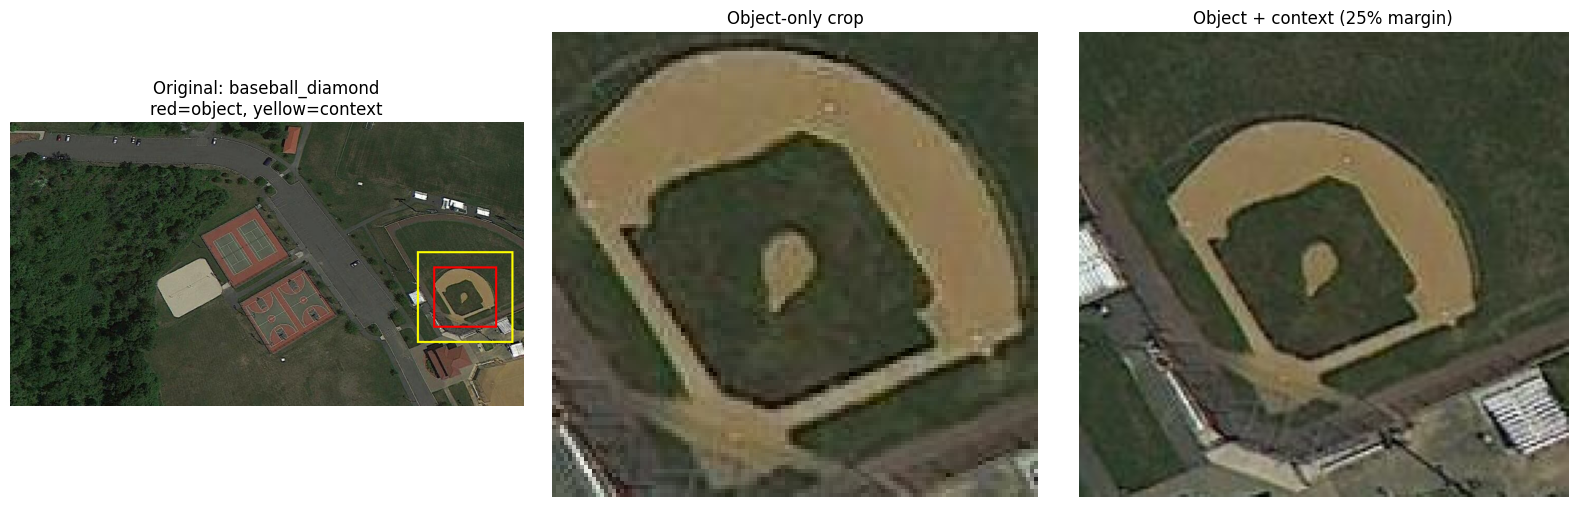

Ground-truth ID: nwpu_vhr10_000742_593_gt_0000
Split: val
Object box: (806, 275, 927, 391)
Context box: (775, 246, 958, 420)


In [143]:
sample = object_records.sample(
    n=1,
    random_state=42,
).iloc[0]

crops = create_object_crops(sample)

annotated_image = crops["full_image"].copy()
drawer = ImageDraw.Draw(annotated_image)

drawer.rectangle(
    crops["context_crop_box"],
    outline="yellow",
    width=4,
)

drawer.rectangle(
    crops["object_crop_box"],
    outline="red",
    width=4,
)

figure, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
)

axes[0].imshow(annotated_image)
axes[0].set_title(
    f"Original: {sample['class_name']}\n"
    "red=object, yellow=context"
)

axes[1].imshow(crops["object_crop"])
axes[1].set_title("Object-only crop")

axes[2].imshow(crops["context_crop"])
axes[2].set_title(
    f"Object + context ({CONTEXT_MARGIN:.0%} margin)"
)

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()

print("Ground-truth ID:", sample["ground_truth_id"])
print("Split:", sample["manifest_split"])
print("Object box:", crops["object_crop_box"])
print("Context box:", crops["context_crop_box"])

## 5. Load RemoteCLIP and validate its embedding contract

RemoteCLIP ViT-B-32 is loaded through OpenCLIP from a checkpoint cached in shared resources. A two-crop smoke test verifies the 512-dimensional output, finite values, and unit L2 norm. With normalized vectors, dot product and cosine-similarity rankings are equivalent.

In [144]:
import open_clip
import torch
import torch.nn.functional as F
from huggingface_hub import hf_hub_download


REMOTECLIP_MODEL_NAME = "ViT-B-32"
REMOTECLIP_REPOSITORY = "chendelong/RemoteCLIP"
REMOTECLIP_FILENAME = (
    f"RemoteCLIP-{REMOTECLIP_MODEL_NAME}.pt"
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

MODEL_CACHE = (
    Path(os.environ["SHARED_RESOURCES_ROOT"])
    / "model_cache"
    / "huggingface"
)
MODEL_CACHE.mkdir(parents=True, exist_ok=True)

checkpoint_path = hf_hub_download(
    repo_id=REMOTECLIP_REPOSITORY,
    filename=REMOTECLIP_FILENAME,
    cache_dir=str(MODEL_CACHE),
)

print("Device:", DEVICE)
print("Checkpoint:", checkpoint_path)

Device: cuda
Checkpoint: /content/drive/Othercomputers/My laptop/shared_resources/model_cache/huggingface/models--chendelong--RemoteCLIP/snapshots/bf1d8a3ccf2ddbf7c875705e46373bfe542bce38/RemoteCLIP-ViT-B-32.pt


In [145]:
remoteclip_model, _, remoteclip_preprocess = (
    open_clip.create_model_and_transforms(
        REMOTECLIP_MODEL_NAME
    )
)

checkpoint = torch.load(
    checkpoint_path,
    map_location="cpu",
)

load_result = remoteclip_model.load_state_dict(checkpoint)

remoteclip_model = remoteclip_model.to(DEVICE)
remoteclip_model.eval()
remoteclip_model.requires_grad_(False)

print("Checkpoint loading:", load_result)

Checkpoint loading: <All keys matched successfully>


In [146]:
@torch.inference_mode()
def encode_remoteclip_images(pil_images):
    batch = torch.stack(
        [
            remoteclip_preprocess(image.convert("RGB"))
            for image in pil_images
        ]
    ).to(DEVICE)

    with torch.autocast(
        device_type=DEVICE.type,
        dtype=torch.float16,
        enabled=DEVICE.type == "cuda",
    ):
        embeddings = remoteclip_model.encode_image(batch)

    # Convert to float32 before normalization and storage.
    embeddings = F.normalize(
        embeddings.float(),
        p=2,
        dim=-1,
    )

    return embeddings.cpu().numpy()

In [147]:
smoke_embeddings = encode_remoteclip_images(
    [
        crops["object_crop"],
        crops["context_crop"],
    ]
)

embedding_norms = np.linalg.norm(
    smoke_embeddings,
    axis=1,
)

similarity_matrix = (
    smoke_embeddings @ smoke_embeddings.T
)

print("Embedding shape:", smoke_embeddings.shape)
print("L2 norms:", embedding_norms)
print("Cosine similarity matrix:")
print(similarity_matrix)

assert smoke_embeddings.ndim == 2
assert smoke_embeddings.shape[0] == 2
assert np.isfinite(smoke_embeddings).all()
assert np.allclose(
    embedding_norms,
    1.0,
    atol=1e-4,
)

Embedding shape: (2, 512)
L2 norms: [0.99999994 1.        ]
Cosine similarity matrix:
[[0.9999999 0.8888577]
 [0.8888577 1.       ]]


## 6. Generate the verified embedding corpus

Images are read from Colab-local storage, and each source image is opened only once. The corpus contains one full-scene embedding per image plus object and context embeddings for every verified ground-truth box. All vectors are converted to float32 and L2-normalized.

In [148]:
local_paths_by_key = (
    manifest.set_index("image_key")["image_path"]
    .map(lambda value: str(RAW_DATASET_ROOT / value))
)

image_records["embedding_image_path"] = (
    image_records["image_key"].map(local_paths_by_key)
)

image_path_by_id = (
    image_records.set_index("image_id")[
        "embedding_image_path"
    ]
)

object_records["embedding_image_path"] = (
    object_records["image_id"].map(image_path_by_id)
)

missing_local_images = image_records[
    ~image_records["embedding_image_path"]
    .map(lambda value: Path(value).is_file())
]

print("Locally accessible images:", len(image_records) - len(missing_local_images))
assert missing_local_images.empty

Locally accessible images: 800


In [149]:
import time

from tqdm.auto import tqdm


EMBEDDING_BATCH_SIZE = 64

pending_images = []
pending_metadata = []

embedding_chunks = []
embedding_rows = []


def flush_embedding_batch():
    if not pending_images:
        return

    vectors = encode_remoteclip_images(pending_images)

    assert len(vectors) == len(pending_metadata)
    assert np.isfinite(vectors).all()

    embedding_chunks.append(vectors.astype(np.float32))
    embedding_rows.extend(pending_metadata)

    pending_images.clear()
    pending_metadata.clear()


def queue_embedding(image, metadata):
    pending_images.append(image)
    pending_metadata.append(metadata)

    if len(pending_images) >= EMBEDDING_BATCH_SIZE:
        flush_embedding_batch()


objects_by_image = {
    image_id: group
    for image_id, group in object_records.groupby(
        "image_id",
        sort=False,
    )
}

start_time = time.perf_counter()

for _, image_row in tqdm(
    image_records.iterrows(),
    total=len(image_records),
    desc="Embedding NWPU images",
):
    with Image.open(
        image_row["embedding_image_path"]
    ) as opened_image:
        image = opened_image.convert("RGB")

    # Full-scene embedding
    queue_embedding(
        image.copy(),
        {
            "embedding_id": (
                f"{image_row['image_id']}::scene"
            ),
            "dataset_id": image_row["dataset_id"],
            "image_id": image_row["image_id"],
            "source_image_path": image_row["source_image_path"],
            "split": image_row["manifest_split"],
            "record_type": "scene",
            "crop_type": "full_image",
            "annotation_source": "ground_truth",
            "source_record_id": "",
            "class_id": -1,
            "class_name": "",
            "xmin": np.nan,
            "ymin": np.nan,
            "xmax": np.nan,
            "ymax": np.nan,
            "context_margin": 0.0,
            "verified": True,
            "eligible_as_evidence": bool(
                image_row["eligible_as_evidence"]
            ),
            "model_name": REMOTECLIP_MODEL_NAME,
            "model_checkpoint": REMOTECLIP_FILENAME,
        },
    )

    image_objects = objects_by_image.get(
        image_row["image_id"]
    )

    if image_objects is None:
        continue

    for _, object_row in image_objects.iterrows():
        object_box = calculate_crop_box(
            object_row,
            image.width,
            image.height,
            margin_fraction=0.0,
        )

        context_box = calculate_crop_box(
            object_row,
            image.width,
            image.height,
            margin_fraction=CONTEXT_MARGIN,
        )

        common_metadata = {
            "dataset_id": object_row["dataset_id"],
            "image_id": object_row["image_id"],
            "source_image_path": object_row["source_image_path"],
            "split": object_row["manifest_split"],
            "record_type": "object",
            "annotation_source": "ground_truth",
            "source_record_id": object_row["ground_truth_id"],
            "class_id": int(object_row["class_id"]),
            "class_name": object_row["class_name"],
            "xmin": float(object_row["xmin"]),
            "ymin": float(object_row["ymin"]),
            "xmax": float(object_row["xmax"]),
            "ymax": float(object_row["ymax"]),
            "verified": True,
            "eligible_as_evidence": bool(
                object_row["eligible_as_evidence"]
            ),
            "model_name": REMOTECLIP_MODEL_NAME,
            "model_checkpoint": REMOTECLIP_FILENAME,
        }

        queue_embedding(
            image.crop(object_box),
            {
                **common_metadata,
                "embedding_id": (
                    f"{object_row['ground_truth_id']}::object"
                ),
                "crop_type": "object",
                "context_margin": 0.0,
            },
        )

        queue_embedding(
            image.crop(context_box),
            {
                **common_metadata,
                "embedding_id": (
                    f"{object_row['ground_truth_id']}::context"
                ),
                "crop_type": "context",
                "context_margin": float(CONTEXT_MARGIN),
            },
        )

flush_embedding_batch()

embedding_matrix = np.concatenate(
    embedding_chunks,
    axis=0,
)

embedding_metadata = pd.DataFrame(
    embedding_rows
)

elapsed_seconds = time.perf_counter() - start_time

Embedding NWPU images:   0%|          | 0/800 [00:00<?, ?it/s]

In [150]:
expected_embeddings = (
    len(image_records)
    + 2 * len(object_records)
)

embedding_norms = np.linalg.norm(
    embedding_matrix,
    axis=1,
)

assert len(embedding_metadata) == expected_embeddings
assert embedding_matrix.shape == (
    expected_embeddings,
    512,
)
assert embedding_metadata["embedding_id"].is_unique
assert np.isfinite(embedding_matrix).all()
assert np.allclose(
    embedding_norms,
    1.0,
    atol=1e-4,
)

print("Expected embeddings:", expected_embeddings)
print("Generated embeddings:", len(embedding_metadata))
print("Embedding matrix:", embedding_matrix.shape)
print(
    "Norm range:",
    embedding_norms.min(),
    embedding_norms.max(),
)
print(f"Elapsed: {elapsed_seconds / 60:.2f} minutes")

display(
    embedding_metadata.groupby(
        ["split", "crop_type", "eligible_as_evidence"]
    ).size().rename("records").reset_index()
)

Expected embeddings: 8592
Generated embeddings: 8592
Embedding matrix: (8592, 512)
Norm range: 0.9999998 1.0000001
Elapsed: 0.61 minutes


,split,crop_type,eligible_as_evidence,records
0,test,context,False,523
1,test,full_image,False,118
2,test,object,False,523
3,train,context,True,2842
4,train,full_image,True,562
5,train,object,True,2842
6,val,context,True,531
7,val,full_image,True,120
8,val,object,True,531


In [151]:
image_key_by_id = (
    image_records.set_index("image_id")["image_key"]
)

relative_path_by_key = (
    manifest.set_index("image_key")["image_path"]
)

embedding_metadata["image_key"] = (
    embedding_metadata["image_id"].map(image_key_by_id)
)

embedding_metadata["dataset_image_path"] = (
    embedding_metadata["image_key"].map(relative_path_by_key)
)

assert embedding_metadata["image_key"].notna().all()
assert embedding_metadata["dataset_image_path"].notna().all()

display(
    embedding_metadata[
        [
            "embedding_id",
            "dataset_id",
            "image_key",
            "dataset_image_path",
            "split",
            "record_type",
            "crop_type",
            "class_name",
            "verified",
            "eligible_as_evidence",
        ]
    ].head()
)

,embedding_id,dataset_id,image_key,dataset_image_path,split,record_type,crop_type,class_name,verified,eligible_as_evidence
0,nwpu_vhr10_000000_001::scene,nwpu_vhr10,negative image set/001.jpg,NWPU VHR-10 dataset/negative image set/001.jpg,train,scene,full_image,,True,True
1,nwpu_vhr10_000001_002::scene,nwpu_vhr10,negative image set/002.jpg,NWPU VHR-10 dataset/negative image set/002.jpg,test,scene,full_image,,True,False
2,nwpu_vhr10_000002_003::scene,nwpu_vhr10,negative image set/003.jpg,NWPU VHR-10 dataset/negative image set/003.jpg,train,scene,full_image,,True,True
3,nwpu_vhr10_000003_004::scene,nwpu_vhr10,negative image set/004.jpg,NWPU VHR-10 dataset/negative image set/004.jpg,train,scene,full_image,,True,True
4,nwpu_vhr10_000004_005::scene,nwpu_vhr10,negative image set/005.jpg,NWPU VHR-10 dataset/negative image set/005.jpg,test,scene,full_image,,True,False


In [152]:
import lancedb
import pyarrow as pa


EMBEDDING_DIMENSION = embedding_matrix.shape[1]

LOCAL_ARTIFACT_ROOT = Path(
    "/content/remoteclip_nwpu_vhr10"
)

LOCAL_DATABASE_PATH = (
    LOCAL_ARTIFACT_ROOT / "lancedb"
)

TABLE_NAME = "remoteclip_embeddings"

LOCAL_ARTIFACT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

metadata_arrow = pa.Table.from_pandas(
    embedding_metadata,
    preserve_index=False,
)

flat_vectors = pa.array(
    embedding_matrix.reshape(-1),
    type=pa.float32(),
)

vector_column = (
    pa.FixedSizeListArray.from_arrays(
        flat_vectors,
        EMBEDDING_DIMENSION,
    )
)

embedding_arrow = metadata_arrow.append_column(
    "vector",
    vector_column,
)

print("Arrow records:", embedding_arrow.num_rows)
print("Vector type:", embedding_arrow.schema.field("vector").type)

if embedding_arrow.num_rows != expected_embeddings:
    raise RuntimeError("Arrow row count does not match verified embeddings")
assert str(
    embedding_arrow.schema.field("vector").type
) == "fixed_size_list<item: float>[512]"

Arrow records: 8592
Vector type: fixed_size_list<item: float>[512]


## 7. Build and reload the local LanceDB reference table

The table stores portable relative image paths, split provenance, crop metadata, model identity, verification flags, and a fixed-size 512-dimensional vector. The active database stays in /content for fast reads and writes.

In [153]:
embedding_arrow

pyarrow.Table
embedding_id: string
dataset_id: string
image_id: string
source_image_path: string
split: string
record_type: string
crop_type: string
annotation_source: string
source_record_id: string
class_id: int64
class_name: string
xmin: double
ymin: double
xmax: double
ymax: double
context_margin: double
verified: bool
eligible_as_evidence: bool
model_name: string
model_checkpoint: string
image_key: string
dataset_image_path: string
vector: fixed_size_list<item: float>[512]
  child 0, item: float
----
embedding_id: [["nwpu_vhr10_000000_001::scene","nwpu_vhr10_000001_002::scene","nwpu_vhr10_000002_003::scene","nwpu_vhr10_000003_004::scene","nwpu_vhr10_000004_005::scene",...,"nwpu_vhr10_000799_650::scene","nwpu_vhr10_000799_650_gt_0000::object","nwpu_vhr10_000799_650_gt_0000::context","nwpu_vhr10_000799_650_gt_0001::object","nwpu_vhr10_000799_650_gt_0001::context"]]
dataset_id: [["nwpu_vhr10","nwpu_vhr10","nwpu_vhr10","nwpu_vhr10","nwpu_vhr10",...,"nwpu_vhr10","nwpu_vhr10","nwpu_vhr1

In [154]:
database = lancedb.connect(
    str(LOCAL_DATABASE_PATH)
)

# This overwrites only the temporary Colab table when rerun.
embedding_table = database.create_table(
    TABLE_NAME,
    data=embedding_arrow,
    mode="overwrite",
    on_bad_vectors="error",
)

print("Database:", LOCAL_DATABASE_PATH)
print("Tables:", database.table_names())
print("Stored records:", embedding_table.count_rows())

if embedding_table.count_rows() != expected_embeddings:
    raise RuntimeError("LanceDB row count does not match verified embeddings")

Database: /content/remoteclip_nwpu_vhr10/lancedb
Tables: ['prediction_embeddings', 'remoteclip_embeddings']
Stored records: 8592


/tmp/ipykernel_820/3333945392.py:14: DeprecationWarning: table_names() is deprecated, use list_tables() instead
  print("Tables:", database.table_names())


In [155]:
del embedding_table
del database

reloaded_database = lancedb.connect(
    str(LOCAL_DATABASE_PATH)
)

embedding_table = reloaded_database.open_table(
    TABLE_NAME
)

print("Reloaded records:", embedding_table.count_rows())
print(embedding_table.schema)

if embedding_table.count_rows() != expected_embeddings:
    raise RuntimeError("Reloaded LanceDB row count mismatch")

Reloaded records: 8592
embedding_id: string
dataset_id: string
image_id: string
source_image_path: string
split: string
record_type: string
crop_type: string
annotation_source: string
source_record_id: string
class_id: int64
class_name: string
xmin: double
ymin: double
xmax: double
ymax: double
context_margin: double
verified: bool
eligible_as_evidence: bool
model_name: string
model_checkpoint: string
image_key: string
dataset_image_path: string
vector: fixed_size_list<item: float>[512]
  child 0, item: float
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 2753


In [156]:
query_candidates = embedding_metadata[
    (embedding_metadata["split"] == "val")
    & (embedding_metadata["crop_type"] == "object")
    & (embedding_metadata["record_type"] == "object")
].copy()

if query_candidates.empty:
    raise RuntimeError("No validation object is available for the smoke test")

query_metadata = query_candidates.sample(
    n=1, random_state=42
).iloc[0]
query_vector = embedding_matrix[int(query_metadata.name)].astype(np.float32)

query_image_label = query_metadata.get(
    "image_key",
    query_metadata.get("dataset_image_path", query_metadata["image_id"]),
)

print("Query embedding:", query_metadata["embedding_id"])
print("Query class:", query_metadata["class_name"])
print("Query split:", query_metadata["split"])
print("Query image:", query_image_label)


Query embedding: nwpu_vhr10_000764_615_gt_0002::object
Query class: tennis_court
Query split: val
Query image: positive image set/615.jpg


## 8. Run an exact cosine-search smoke test

A validation object is used as the query while the metadata pre-filter admits only verified train object crops of the same crop variant. The search intentionally remains unindexed so this small baseline uses exact nearest neighbours.

In [157]:
query_image_id = str(
    query_metadata["image_id"]
).replace("'", "''")

evidence_filter = (
    "verified = true "
    "AND eligible_as_evidence = true "
    "AND split = 'train' "
    "AND record_type = 'object' "
    "AND crop_type = 'object' "
    f"AND image_id != '{query_image_id}'"
)

retrieval_results = (
    embedding_table
    .search(query_vector)
    .distance_type("cosine")
    .where(evidence_filter, prefilter=True)
    .select(
        [
            "embedding_id",
            "image_id",
            "image_key",
            "dataset_image_path",
            "split",
            "class_id",
            "class_name",
            "crop_type",
            "xmin",
            "ymin",
            "xmax",
            "ymax",
            "verified",
            "eligible_as_evidence",
        ]
    )
    .limit(5)
    .to_pandas()
)

retrieval_results["cosine_similarity"] = (
    1.0 - retrieval_results["_distance"]
)

assert len(retrieval_results) == 5
assert set(retrieval_results["split"]) == {"train"}
assert retrieval_results["verified"].all()
assert retrieval_results["eligible_as_evidence"].all()
assert not (
    retrieval_results["image_id"]
    == query_metadata["image_id"]
).any()

display(
    retrieval_results[
        [
            "class_name",
            "split",
            "crop_type",
            "image_key",
            "cosine_similarity",
        ]
    ]
)

,class_name,split,crop_type,image_key,cosine_similarity
0,tennis_court,train,object,positive image set/156.jpg,0.917296
1,tennis_court,train,object,positive image set/156.jpg,0.895233
2,basketball_court,train,object,positive image set/457.jpg,0.889495
3,tennis_court,train,object,positive image set/119.jpg,0.889472
4,tennis_court,train,object,positive image set/619.jpg,0.887990


In [158]:
def load_crop_from_record(record):
    image_path = (
        RAW_DATASET_ROOT
        / str(record["dataset_image_path"])
    )

    with Image.open(image_path) as opened_image:
        image = opened_image.convert("RGB")

    crop_type = record["crop_type"]

    if crop_type == "full_image":
        return image

    xmin = float(record["xmin"])
    ymin = float(record["ymin"])
    xmax = float(record["xmax"])
    ymax = float(record["ymax"])

    margin_fraction = (
        CONTEXT_MARGIN
        if crop_type == "context"
        else 0.0
    )

    box_width = xmax - xmin
    box_height = ymax - ymin

    margin_x = box_width * margin_fraction
    margin_y = box_height * margin_fraction

    crop_box = (
        max(0, math.floor(xmin - margin_x)),
        max(0, math.floor(ymin - margin_y)),
        min(image.width, math.ceil(xmax + margin_x)),
        min(image.height, math.ceil(ymax + margin_y)),
    )

    return image.crop(crop_box)

In [159]:
retrieval_results["class_match"] = (
    retrieval_results["class_id"].astype(int)
    == int(query_metadata["class_id"])
)

precision_at_5 = retrieval_results[
    "class_match"
].mean()

print("Query class:", query_metadata["class_name"])
print(f"Single-query Precision@5: {precision_at_5:.2f}")

display(
    retrieval_results[
        [
            "class_name",
            "cosine_similarity",
            "class_match",
            "image_key",
        ]
    ]
)

Query class: tennis_court
Single-query Precision@5: 0.80


,class_name,cosine_similarity,class_match,image_key
0,tennis_court,0.917296,True,positive image set/156.jpg
1,tennis_court,0.895233,True,positive image set/156.jpg
2,basketball_court,0.889495,False,positive image set/457.jpg
3,tennis_court,0.889472,True,positive image set/119.jpg
4,tennis_court,0.887990,True,positive image set/619.jpg


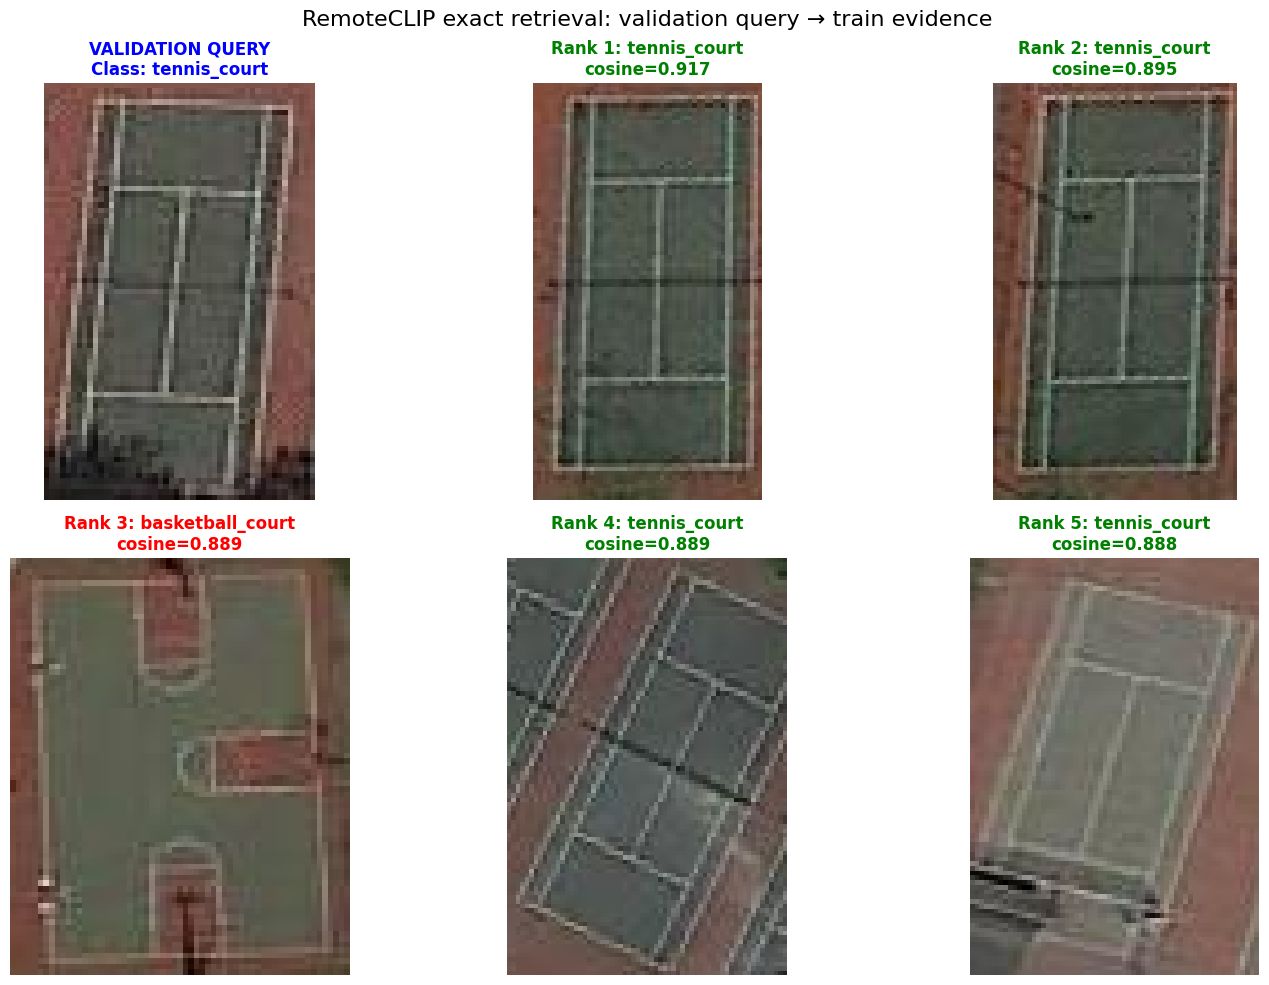

In [160]:
query_crop = load_crop_from_record(
    query_metadata
)

figure, axes = plt.subplots(
    2,
    3,
    figsize=(15, 10),
)

axes = axes.flatten()

axes[0].imshow(query_crop)
axes[0].set_title(
    "VALIDATION QUERY\n"
    f"Class: {query_metadata['class_name']}",
    color="blue",
    fontweight="bold",
)

for rank, (_, result) in enumerate(
    retrieval_results.iterrows(),
    start=1,
):
    axis = axes[rank]
    retrieved_crop = load_crop_from_record(result)

    title_color = (
        "green"
        if result["class_match"]
        else "red"
    )

    axis.imshow(retrieved_crop)
    axis.set_title(
        f"Rank {rank}: {result['class_name']}\n"
        f"cosine={result['cosine_similarity']:.3f}",
        color=title_color,
        fontweight="bold",
    )

for axis in axes:
    axis.axis("off")

figure.suptitle(
    "RemoteCLIP exact retrieval: "
    "validation query → train evidence",
    fontsize=16,
)

plt.tight_layout()
plt.show()

## 9. Enforce diverse, leakage-safe evidence

The retrieval helper applies the evidence policy before vector search, excludes the current image, and keeps at most one result per source image. It expands the candidate pool when duplicate objects leave fewer than top-k unique images. This prevents a dense multi-object image from dominating all evidence without failing on crowded scenes.

In [161]:
def sql_literal(value):
    escaped = str(value).replace("'", "''")
    return f"'{escaped}'"


def retrieve_unique_image_evidence(
    query_vector,
    query_image_id,
    crop_type,
    evidence_splits=("train",),
    top_k=5,
    candidate_limit=100,
):
    split_values = ", ".join(
        sql_literal(split)
        for split in evidence_splits
    )

    evidence_filter = (
        "verified = true "
        "AND eligible_as_evidence = true "
        f"AND split IN ({split_values}) "
        "AND record_type = 'object' "
        f"AND crop_type = {sql_literal(crop_type)} "
        f"AND image_id != {sql_literal(query_image_id)}"
    )

    selected_columns = [
        "embedding_id", "image_id", "image_key",
        "dataset_image_path", "split", "class_id",
        "class_name", "crop_type", "xmin", "ymin",
        "xmax", "ymax", "verified",
        "eligible_as_evidence",
    ]
    search_limit = max(top_k, candidate_limit)
    maximum_limit = embedding_table.count_rows()

    while True:
        candidates = (
            embedding_table
            .search(np.asarray(query_vector, dtype=np.float32))
            .distance_type("cosine")
            .where(evidence_filter, prefilter=True)
            .select(selected_columns)
            .limit(search_limit)
            .to_pandas()
        )

        results = (
            candidates
            .sort_values("_distance")
            .drop_duplicates(subset="image_id", keep="first")
            .head(top_k)
            .reset_index(drop=True)
        )

        exhausted_matches = len(candidates) < search_limit
        if len(results) >= top_k or exhausted_matches:
            break
        if search_limit >= maximum_limit:
            break
        search_limit = min(search_limit * 2, maximum_limit)

    results["cosine_similarity"] = 1.0 - results["_distance"]
    return results

In [162]:
retrieval_results = retrieve_unique_image_evidence(
    query_vector=query_vector,
    query_image_id=query_metadata["image_id"],
    crop_type="object",
    evidence_splits=("train",),
    top_k=5,
)

retrieval_results["class_match"] = (
    retrieval_results["class_id"].astype(int)
    == int(query_metadata["class_id"])
)

precision_at_5 = retrieval_results[
    "class_match"
].mean()

assert retrieval_results["image_id"].is_unique
assert set(retrieval_results["split"]) == {"train"}
assert len(retrieval_results) == 5

print("Query class:", query_metadata["class_name"])
print(f"Unique-image Precision@5: {precision_at_5:.2f}")

display(
    retrieval_results[
        [
            "class_name",
            "cosine_similarity",
            "class_match",
            "image_key",
        ]
    ]
)

Query class: tennis_court
Unique-image Precision@5: 0.80


,class_name,cosine_similarity,class_match,image_key
0,tennis_court,0.917296,True,positive image set/156.jpg
1,basketball_court,0.889495,False,positive image set/457.jpg
2,tennis_court,0.889472,True,positive image set/119.jpg
3,tennis_court,0.887990,True,positive image set/619.jpg
4,tennis_court,0.885769,True,positive image set/216.jpg


## 10. Evaluate oracle retrieval on validation objects

This experiment uses perfect validation ground-truth crops as queries and verified train crops as evidence. Relevance means matching the ground-truth class. These metrics are an oracle upper bound: real annotation queries use imperfect detector boxes.

In [163]:
TOP_K = 5
CANDIDATE_LIMIT = 100

embedding_position_by_id = {
    embedding_id: position
    for position, embedding_id in enumerate(
        embedding_metadata["embedding_id"]
    )
}

train_evidence_metadata = embedding_metadata[
    (embedding_metadata["split"] == "train")
    & (embedding_metadata["record_type"] == "object")
    & (embedding_metadata["verified"])
]

# Recall denominator: number of unique train evidence images
# containing the relevant class.
relevant_image_counts = (
    train_evidence_metadata
    .groupby(["crop_type", "class_id"])["image_id"]
    .nunique()
    .to_dict()
)


def evaluate_retrieval_query(
    query_metadata,
    query_vector,
    top_k=TOP_K,
):
    results = retrieve_unique_image_evidence(
        query_vector=query_vector,
        query_image_id=query_metadata["image_id"],
        crop_type=query_metadata["crop_type"],
        evidence_splits=("train",),
        top_k=top_k,
        candidate_limit=CANDIDATE_LIMIT,
    )

    if len(results) < top_k:
        raise RuntimeError(
            f"Only {len(results)} unique images returned for "
            f"{query_metadata['embedding_id']}. Increase "
            "CANDIDATE_LIMIT."
        )

    relevant = (
        results["class_id"].astype(int).to_numpy()
        == int(query_metadata["class_id"])
    )

    cumulative_relevant = np.cumsum(relevant)
    precision_by_rank = (
        cumulative_relevant
        / np.arange(1, top_k + 1)
    )

    total_relevant_images = relevant_image_counts[
        (
            query_metadata["crop_type"],
            int(query_metadata["class_id"]),
        )
    ]

    average_precision_at_k = (
        np.sum(
            precision_by_rank * relevant
        )
        / min(total_relevant_images, top_k)
    )

    relevant_ranks = np.flatnonzero(relevant) + 1

    reciprocal_rank = (
        1.0 / relevant_ranks[0]
        if len(relevant_ranks)
        else 0.0
    )

    return {
        "query_embedding_id": query_metadata["embedding_id"],
        "query_source_record_id": query_metadata["source_record_id"],
        "query_image_id": query_metadata["image_id"],
        "query_image_key": query_metadata["image_key"],
        "class_id": int(query_metadata["class_id"]),
        "class_name": query_metadata["class_name"],
        "crop_type": query_metadata["crop_type"],
        "precision_at_1": float(relevant[0]),
        "precision_at_5": float(relevant.mean()),
        "hit_at_5": float(relevant.any()),
        "recall_at_5": float(
            relevant.sum() / total_relevant_images
        ),
        "average_precision_at_5": float(
            average_precision_at_k
        ),
        "reciprocal_rank_at_5": float(
            reciprocal_rank
        ),
        "top_1_similarity": float(
            results.iloc[0]["cosine_similarity"]
        ),
        "mean_top_5_similarity": float(
            results["cosine_similarity"].mean()
        ),
        "relevant_retrieved_at_5": int(
            relevant.sum()
        ),
        "available_relevant_images": int(
            total_relevant_images
        ),
    }

In [164]:
validation_queries = embedding_metadata[
    (embedding_metadata["split"] == "val")
    & (embedding_metadata["record_type"] == "object")
    & (
        embedding_metadata["crop_type"].isin(
            ["object", "context"]
        )
    )
].copy()

expected_queries = (
    2
    * object_records[
        object_records["manifest_split"] == "val"
    ].shape[0]
)

if len(validation_queries) != expected_queries:
    raise RuntimeError("Validation query count does not match verified objects")

evaluation_rows = []

evaluation_start = time.perf_counter()

for _, query_row in tqdm(
    validation_queries.iterrows(),
    total=len(validation_queries),
    desc="Evaluating validation retrieval",
):
    position = embedding_position_by_id[
        query_row["embedding_id"]
    ]

    query_embedding = embedding_matrix[
        position
    ]

    evaluation_rows.append(
        evaluate_retrieval_query(
            query_metadata=query_row,
            query_vector=query_embedding,
            top_k=TOP_K,
        )
    )

retrieval_evaluation = pd.DataFrame(
    evaluation_rows
)

evaluation_seconds = (
    time.perf_counter() - evaluation_start
)

print(
    "Evaluated queries:",
    len(retrieval_evaluation),
)

print(
    f"Evaluation time: "
    f"{evaluation_seconds:.2f} seconds"
)

if len(retrieval_evaluation) != expected_queries:
    raise RuntimeError("Oracle retrieval evaluation lost queries")
if not retrieval_evaluation["query_embedding_id"].is_unique:
    raise RuntimeError("Oracle retrieval query IDs are not unique")

Evaluating validation retrieval:   0%|          | 0/1062 [00:00<?, ?it/s]

Evaluated queries: 1062
Evaluation time: 39.83 seconds


In [165]:
retrieval_summary = (
    retrieval_evaluation
    .groupby("crop_type")
    .agg(
        queries=("query_embedding_id", "size"),
        precision_at_1=("precision_at_1", "mean"),
        precision_at_5=("precision_at_5", "mean"),
        hit_at_5=("hit_at_5", "mean"),
        recall_at_5=("recall_at_5", "mean"),
        map_at_5=(
            "average_precision_at_5",
            "mean",
        ),
        mrr_at_5=(
            "reciprocal_rank_at_5",
            "mean",
        ),
        mean_top_1_similarity=(
            "top_1_similarity",
            "mean",
        ),
    )
    .reset_index()
)

display(
    retrieval_summary.round(4)
)

,crop_type,queries,precision_at_1,precision_at_5,hit_at_5,recall_at_5,map_at_5,mrr_at_5,mean_top_1_similarity
0,context,531,0.9962,0.9849,0.9962,0.1012,0.9830,0.9962,0.9516
1,object,531,0.9925,0.9725,0.9962,0.0996,0.9657,0.9933,0.9525


In [166]:
comparison_metrics = [
    "precision_at_1",
    "precision_at_5",
    "hit_at_5",
    "recall_at_5",
    "map_at_5",
    "mrr_at_5",
]

crop_comparison = (
    retrieval_summary
    .set_index("crop_type")[
        comparison_metrics
    ]
    .transpose()
)

crop_comparison[
    "context_minus_object"
] = (
    crop_comparison["context"]
    - crop_comparison["object"]
)

display(
    crop_comparison.round(4)
)

crop_type,context,object,context_minus_object
precision_at_1,0.9962,0.9925,0.0038
precision_at_5,0.9849,0.9725,0.0124
hit_at_5,0.9962,0.9962,0.0000
recall_at_5,0.1012,0.0996,0.0016
map_at_5,0.9830,0.9657,0.0173
mrr_at_5,0.9962,0.9933,0.0029


In [167]:
per_class_retrieval = (
    retrieval_evaluation
    .groupby(
        [
            "crop_type",
            "class_id",
            "class_name",
        ]
    )
    .agg(
        queries=("query_embedding_id", "size"),
        precision_at_1=("precision_at_1", "mean"),
        precision_at_5=("precision_at_5", "mean"),
        hit_at_5=("hit_at_5", "mean"),
        map_at_5=(
            "average_precision_at_5",
            "mean",
        ),
        mrr_at_5=(
            "reciprocal_rank_at_5",
            "mean",
        ),
    )
    .reset_index()
    .sort_values(
        ["class_id", "crop_type"]
    )
)

display(
    per_class_retrieval.round(4)
)

,crop_type,class_id,class_name,queries,precision_at_1,precision_at_5,hit_at_5,map_at_5,mrr_at_5
0,context,0,airplane,144,1.0000,0.9972,1.0000,0.9972,1.0000
10,object,0,airplane,144,1.0000,0.9986,1.0000,0.9986,1.0000
1,context,1,ship,53,0.9811,0.9245,0.9811,0.9138,0.9811
11,object,1,ship,53,0.9245,0.8453,0.9623,0.8069,0.9330
2,context,2,storage_tank,60,1.0000,1.0000,1.0000,1.0000,1.0000
12,object,2,storage_tank,60,1.0000,1.0000,1.0000,1.0000,1.0000
3,context,3,baseball_diamond,65,1.0000,1.0000,1.0000,1.0000,1.0000
13,object,3,baseball_diamond,65,1.0000,0.9969,1.0000,0.9969,1.0000
4,context,4,tennis_court,59,1.0000,0.9763,1.0000,0.9719,1.0000
14,object,4,tennis_court,59,1.0000,0.9661,1.0000,0.9483,1.0000


## 11. Validate prediction-comparison accounting

The comparison export distinguishes true positives, false positives, false negatives, and class errors. Prediction-associated rows must account for every detection, while matched predictions plus false negatives must account for every ground-truth object.

In [168]:
print("Comparison rows:", len(comparisons))
print("\nColumns:")
print(comparisons.columns.tolist())

display(comparisons.head(10))

for column in comparisons.columns:
    if any(
        keyword in column.casefold()
        for keyword in [
            "status",
            "match",
            "correct",
            "outcome",
        ]
    ):
        print(f"\n{column}:")
        display(
            comparisons[column]
            .value_counts(
                dropna=False
            )
            .head(20)
        )

Comparison rows: 4892

Columns:
['comparison_id', 'image_id', 'detection_id', 'ground_truth_id', 'iou', 'status']


,comparison_id,image_id,detection_id,ground_truth_id,iou,status
0,nwpu_vhr10_000006_007_cmp_0000,nwpu_vhr10_000006_007,nwpu_vhr10_000006_007_det_0000,NaN,NaN,false_positive
1,nwpu_vhr10_000006_007_cmp_0001,nwpu_vhr10_000006_007,nwpu_vhr10_000006_007_det_0001,NaN,NaN,false_positive
2,nwpu_vhr10_000009_010_cmp_0000,nwpu_vhr10_000009_010,nwpu_vhr10_000009_010_det_0000,NaN,NaN,false_positive
3,nwpu_vhr10_000012_013_cmp_0000,nwpu_vhr10_000012_013,nwpu_vhr10_000012_013_det_0000,NaN,NaN,false_positive
4,nwpu_vhr10_000012_013_cmp_0001,nwpu_vhr10_000012_013,nwpu_vhr10_000012_013_det_0001,NaN,NaN,false_positive
5,nwpu_vhr10_000020_021_cmp_0000,nwpu_vhr10_000020_021,nwpu_vhr10_000020_021_det_0000,NaN,NaN,false_positive
6,nwpu_vhr10_000021_022_cmp_0000,nwpu_vhr10_000021_022,nwpu_vhr10_000021_022_det_0000,NaN,NaN,false_positive
7,nwpu_vhr10_000026_027_cmp_0000,nwpu_vhr10_000026_027,nwpu_vhr10_000026_027_det_0000,NaN,NaN,false_positive
8,nwpu_vhr10_000029_030_cmp_0000,nwpu_vhr10_000029_030,nwpu_vhr10_000029_030_det_0000,NaN,NaN,false_positive
9,nwpu_vhr10_000031_032_cmp_0000,nwpu_vhr10_000031_032,nwpu_vhr10_000031_032_det_0000,NaN,NaN,false_positive



status:


,count
status,
true_positive,3850
false_positive,996
false_negative,23
class_error,23


In [169]:
possible_id_columns = [
    column
    for column in comparisons.columns
    if column.endswith("_id")
]

print("ID columns:", possible_id_columns)

display(
    comparisons[possible_id_columns].head()
)

ID columns: ['comparison_id', 'image_id', 'detection_id', 'ground_truth_id']


,comparison_id,image_id,detection_id,ground_truth_id
0,nwpu_vhr10_000006_007_cmp_0000,nwpu_vhr10_000006_007,nwpu_vhr10_000006_007_det_0000,NaN
1,nwpu_vhr10_000006_007_cmp_0001,nwpu_vhr10_000006_007,nwpu_vhr10_000006_007_det_0001,NaN
2,nwpu_vhr10_000009_010_cmp_0000,nwpu_vhr10_000009_010,nwpu_vhr10_000009_010_det_0000,NaN
3,nwpu_vhr10_000012_013_cmp_0000,nwpu_vhr10_000012_013,nwpu_vhr10_000012_013_det_0000,NaN
4,nwpu_vhr10_000012_013_cmp_0001,nwpu_vhr10_000012_013,nwpu_vhr10_000012_013_det_0001,NaN


In [170]:
print(
    comparisons.dtypes
    .rename("dtype")
    .to_string()
)

print("\nFirst comparison record:")
display(
    comparisons.head(1).transpose()
)

comparison_id       object
image_id            object
detection_id        object
ground_truth_id     object
iou                float64
status              object

First comparison record:


,0
comparison_id,nwpu_vhr10_000006_007_cmp_0000
image_id,nwpu_vhr10_000006_007
detection_id,nwpu_vhr10_000006_007_det_0000
ground_truth_id,NaN
iou,NaN
status,false_positive


In [171]:
status_counts = comparisons[
    "status"
].value_counts()

prediction_comparison_count = (
    status_counts.get("true_positive", 0)
    + status_counts.get("false_positive", 0)
    + status_counts.get("class_error", 0)
)

ground_truth_accounting_count = (
    status_counts.get("true_positive", 0)
    + status_counts.get("class_error", 0)
    + status_counts.get("false_negative", 0)
)

assert prediction_comparison_count == len(detections)
assert ground_truth_accounting_count == len(ground_truth)

print("Prediction rows accounted for:", prediction_comparison_count)
print("Ground-truth objects accounted for:", ground_truth_accounting_count)

Prediction rows accounted for: 4869
Ground-truth objects accounted for: 3896


## 12. Build unverified detector-query records

Detector predictions are query candidates, not evidence. They retain detector confidence, comparison status, IoU, and matched ground-truth metadata when available. Every prediction is stored with verified=False and eligible_as_evidence=False; false negatives are saved separately because they have no predicted crop.

In [172]:
prediction_comparisons = comparisons[
    comparisons["detection_id"].notna()
][
    [
        "comparison_id",
        "image_id",
        "detection_id",
        "ground_truth_id",
        "iou",
        "status",
    ]
].copy()

assert len(prediction_comparisons) == len(detections)
assert prediction_comparisons["detection_id"].is_unique
assert "false_negative" not in set(
    prediction_comparisons["status"]
)

prediction_records = detections.merge(
    prediction_comparisons,
    on=["image_id", "detection_id"],
    how="inner",
    validate="one_to_one",
)

prediction_records = prediction_records.merge(
    images_with_split[
        [
            "image_id",
            "dataset_id",
            "source_image_path",
            "image_key",
            "manifest_split",
            "image_width",
            "image_height",
        ]
    ],
    on="image_id",
    how="left",
    validate="many_to_one",
)

prediction_records["embedding_image_path"] = (
    prediction_records["image_id"]
    .map(image_path_by_id)
)

prediction_records["dataset_image_path"] = (
    prediction_records["image_key"]
    .map(relative_path_by_key)
)

In [173]:
ground_truth_lookup = ground_truth[
    [
        "ground_truth_id",
        "class_id",
        "class_name",
        "xmin",
        "ymin",
        "xmax",
        "ymax",
    ]
].rename(
    columns={
        "class_id": "true_class_id",
        "class_name": "true_class_name",
        "xmin": "true_xmin",
        "ymin": "true_ymin",
        "xmax": "true_xmax",
        "ymax": "true_ymax",
    }
)

prediction_records = prediction_records.merge(
    ground_truth_lookup,
    on="ground_truth_id",
    how="left",
    validate="many_to_one",
)

prediction_records["record_type"] = "prediction"
prediction_records["annotation_source"] = "prediction"
prediction_records["verified"] = False
prediction_records["eligible_as_evidence"] = False

In [174]:
# Confirm that the ground-truth join ran exactly once.
required_prediction_columns = {
    "true_class_id",
    "true_class_name",
    "true_xmin",
    "true_ymin",
    "true_xmax",
    "true_ymax",
}

assert required_prediction_columns.issubset(
    prediction_records.columns
)
assert not any(
    column.endswith(("_x", "_y"))
    and column[:-2] in required_prediction_columns
    for column in prediction_records.columns
)

In [175]:
if len(prediction_records) != len(detections):
    raise RuntimeError(
        f"Prediction join lost rows: {len(prediction_records)} != {len(detections)}"
    )
if not prediction_records["detection_id"].is_unique:
    raise RuntimeError("Detection IDs are not unique")
if prediction_records["manifest_split"].isna().any():
    raise RuntimeError("Some predictions have no manifest split")
if prediction_records["embedding_image_path"].isna().any():
    raise RuntimeError("Some predictions have no accessible image path")

matched = prediction_records["status"].isin(["true_positive", "class_error"])
false_positive = prediction_records["status"] == "false_positive"
if prediction_records.loc[matched, "ground_truth_id"].isna().any():
    raise RuntimeError("Matched predictions are missing ground truth")
if prediction_records.loc[false_positive, "ground_truth_id"].notna().any():
    raise RuntimeError("False-positive predictions unexpectedly match ground truth")


In [176]:
missed_ground_truth_records = (
    comparisons[comparisons["status"] == "false_negative"]
    [["comparison_id", "image_id", "ground_truth_id", "status"]]
    .merge(
        ground_truth,
        on=["image_id", "ground_truth_id"],
        how="inner",
        validate="one_to_one",
    )
    .merge(
        images_with_split[["image_id", "manifest_split"]],
        on="image_id",
        how="left",
        validate="many_to_one",
    )
)

expected_false_negatives = int(
    (comparisons["status"] == "false_negative").sum()
)
if len(missed_ground_truth_records) != expected_false_negatives:
    raise RuntimeError(
        "False-negative accounting mismatch: "
        f"{len(missed_ground_truth_records)} != {expected_false_negatives}"
    )


In [177]:
display(
    prediction_records.groupby(
        ["manifest_split", "status"]
    )
    .size()
    .rename("predictions")
    .reset_index()
)

display(
    prediction_records.groupby(
        ["manifest_split", "status"]
    )["confidence"]
    .agg(
        predictions="count",
        minimum="min",
        median="median",
        mean="mean",
        maximum="max",
    )
    .reset_index()
    .round(4)
)

display(
    missed_ground_truth_records.groupby(
        "manifest_split"
    )
    .size()
    .rename("false_negatives")
    .reset_index()
)

,manifest_split,status,predictions
0,test,class_error,2
1,test,false_positive,148
2,test,true_positive,507
3,train,class_error,21
4,train,false_positive,702
5,train,true_positive,2821
6,val,false_positive,146
7,val,true_positive,522


,manifest_split,status,predictions,minimum,median,mean,maximum
0,test,class_error,2,0.2433,0.5302,0.5302,0.8171
1,test,false_positive,148,0.0505,0.2147,0.3118,0.8766
2,test,true_positive,507,0.0522,0.8518,0.8162,0.9504
3,train,class_error,21,0.0526,0.1059,0.1463,0.3844
4,train,false_positive,702,0.0500,0.1452,0.2286,0.8833
5,train,true_positive,2821,0.0623,0.8604,0.8452,0.9567
6,val,false_positive,146,0.0503,0.1894,0.3001,0.9022
7,val,true_positive,522,0.0691,0.8579,0.8244,0.9515


,manifest_split,false_negatives
0,test,14
1,val,9


## 13. Embed detector-predicted crops

Every detection produces object and context embeddings. Train, validation, and test predictions may be stored for provenance, but only validation predictions are used during development evaluation.

In [178]:
PREDICTION_BATCH_SIZE = 64

pending_prediction_images = []
pending_prediction_metadata = []

prediction_embedding_chunks = []
prediction_embedding_rows = []


def flush_prediction_batch():
    if not pending_prediction_images:
        return

    vectors = encode_remoteclip_images(
        pending_prediction_images
    )

    assert len(vectors) == len(
        pending_prediction_metadata
    )
    assert np.isfinite(vectors).all()

    prediction_embedding_chunks.append(
        vectors.astype(np.float32)
    )
    prediction_embedding_rows.extend(
        pending_prediction_metadata
    )

    pending_prediction_images.clear()
    pending_prediction_metadata.clear()


def queue_prediction_embedding(image, metadata):
    pending_prediction_images.append(image)
    pending_prediction_metadata.append(metadata)

    if (
        len(pending_prediction_images)
        >= PREDICTION_BATCH_SIZE
    ):
        flush_prediction_batch()


def integer_or_default(value, default=-1):
    return (
        default
        if pd.isna(value)
        else int(value)
    )


def string_or_empty(value):
    return (
        ""
        if pd.isna(value)
        else str(value)
    )

In [179]:
prediction_start = time.perf_counter()

for image_id, image_predictions in tqdm(
    prediction_records.groupby(
        "image_id",
        sort=False,
    ),
    total=prediction_records["image_id"].nunique(),
    desc="Embedding detector predictions",
):
    first_record = image_predictions.iloc[0]

    with Image.open(
        first_record["embedding_image_path"]
    ) as opened_image:
        image = opened_image.convert("RGB")

    for _, prediction in image_predictions.iterrows():
        object_box = calculate_crop_box(
            prediction,
            image.width,
            image.height,
            margin_fraction=0.0,
        )

        context_box = calculate_crop_box(
            prediction,
            image.width,
            image.height,
            margin_fraction=CONTEXT_MARGIN,
        )

        common_metadata = {
            "dataset_id": prediction["dataset_id"],
            "image_id": prediction["image_id"],
            "image_key": prediction["image_key"],
            "dataset_image_path": prediction[
                "dataset_image_path"
            ],
            "source_image_path": prediction[
                "source_image_path"
            ],
            "split": prediction["manifest_split"],
            "record_type": "prediction",
            "annotation_source": "prediction",
            "source_record_id": prediction["detection_id"],
            "detection_id": prediction["detection_id"],
            "comparison_id": prediction["comparison_id"],
            "comparison_status": prediction["status"],
            "ground_truth_id": string_or_empty(
                prediction["ground_truth_id"]
            ),
            "class_id": int(
                prediction["predicted_class_id"]
            ),
            "class_name": prediction[
                "predicted_class_name"
            ],
            "true_class_id": integer_or_default(
                prediction["true_class_id"]
            ),
            "true_class_name": string_or_empty(
                prediction["true_class_name"]
            ),
            "confidence": float(
                prediction["confidence"]
            ),
            "iou": (
                np.nan
                if pd.isna(prediction["iou"])
                else float(prediction["iou"])
            ),
            "xmin": float(prediction["xmin"]),
            "ymin": float(prediction["ymin"]),
            "xmax": float(prediction["xmax"]),
            "ymax": float(prediction["ymax"]),
            "verified": False,
            "eligible_as_evidence": False,
            "model_name": REMOTECLIP_MODEL_NAME,
            "model_checkpoint": REMOTECLIP_FILENAME,
        }

        queue_prediction_embedding(
            image.crop(object_box),
            {
                **common_metadata,
                "embedding_id": (
                    f"{prediction['detection_id']}::object"
                ),
                "crop_type": "object",
                "context_margin": 0.0,
            },
        )

        queue_prediction_embedding(
            image.crop(context_box),
            {
                **common_metadata,
                "embedding_id": (
                    f"{prediction['detection_id']}::context"
                ),
                "crop_type": "context",
                "context_margin": float(
                    CONTEXT_MARGIN
                ),
            },
        )

flush_prediction_batch()

prediction_embedding_matrix = np.concatenate(
    prediction_embedding_chunks,
    axis=0,
)

prediction_embedding_metadata = pd.DataFrame(
    prediction_embedding_rows
)

prediction_elapsed = (
    time.perf_counter() - prediction_start
)

Embedding detector predictions:   0%|          | 0/692 [00:00<?, ?it/s]

In [180]:
expected_prediction_embeddings = 2 * len(prediction_records)
prediction_norms = np.linalg.norm(prediction_embedding_matrix, axis=1)

if prediction_embedding_matrix.shape != (
    expected_prediction_embeddings,
    EMBEDDING_DIMENSION,
):
    raise RuntimeError(
        f"Unexpected prediction embedding shape: {prediction_embedding_matrix.shape}"
    )
if not prediction_embedding_metadata["embedding_id"].is_unique:
    raise RuntimeError("Prediction embedding IDs are not unique")
if prediction_embedding_metadata["verified"].any():
    raise RuntimeError("Unverified prediction queries were marked verified")
if prediction_embedding_metadata["eligible_as_evidence"].any():
    raise RuntimeError("Prediction queries entered the evidence pool")
if not np.allclose(prediction_norms, 1.0, atol=1e-4):
    raise RuntimeError("Prediction embeddings are not L2-normalized")

print("Prediction embeddings:", len(prediction_embedding_metadata))
print("Embedding matrix:", prediction_embedding_matrix.shape)
print("Norm range:", prediction_norms.min(), prediction_norms.max())
print(f"Elapsed: {prediction_elapsed / 60:.2f} minutes")

display(
    prediction_embedding_metadata.groupby(
        ["split", "comparison_status", "crop_type"]
    ).size().rename("embeddings").reset_index()
)


Prediction embeddings: 9738
Embedding matrix: (9738, 512)
Norm range: 0.9999999 1.0000001
Elapsed: 0.62 minutes


,split,comparison_status,crop_type,embeddings
0,test,class_error,context,2
1,test,class_error,object,2
2,test,false_positive,context,148
3,test,false_positive,object,148
4,test,true_positive,context,507
5,test,true_positive,object,507
6,train,class_error,context,21
7,train,class_error,object,21
8,train,false_positive,context,702
9,train,false_positive,object,702


## 14. Store prediction embeddings separately

The local LanceDB database uses two tables: remoteclip_embeddings for scenes and verified ground-truth crops, and prediction_embeddings for unverified detector queries. This structural separation prevents predictions from accidentally entering the evidence pool.

In [181]:
PREDICTION_TABLE_NAME = "prediction_embeddings"

prediction_metadata_arrow = pa.Table.from_pandas(
    prediction_embedding_metadata,
    preserve_index=False,
)
prediction_flat_vectors = pa.array(
    prediction_embedding_matrix.reshape(-1),
    type=pa.float32(),
)
prediction_vector_column = pa.FixedSizeListArray.from_arrays(
    prediction_flat_vectors,
    EMBEDDING_DIMENSION,
)
prediction_embedding_arrow = prediction_metadata_arrow.append_column(
    "vector",
    prediction_vector_column,
)

if prediction_embedding_arrow.num_rows != expected_prediction_embeddings:
    raise RuntimeError("Prediction Arrow row count does not match embeddings")


In [182]:
prediction_table = reloaded_database.create_table(
    PREDICTION_TABLE_NAME,
    data=prediction_embedding_arrow,
    mode="overwrite",
    on_bad_vectors="error",
)

if prediction_table.count_rows() != expected_prediction_embeddings:
    raise RuntimeError("Prediction table row count does not match embeddings")


In [183]:
if embedding_table.count_rows() != expected_embeddings:
    raise RuntimeError("Verified evidence table row count changed unexpectedly")
if prediction_table.count_rows() != expected_prediction_embeddings:
    raise RuntimeError("Prediction table row count changed unexpectedly")

print("Verified/reference embeddings:", embedding_table.count_rows())
print("Unverified prediction embeddings:", prediction_table.count_rows())
print(
    "Total stored vectors:",
    embedding_table.count_rows() + prediction_table.count_rows(),
)


Verified/reference embeddings: 8592
Unverified prediction embeddings: 9738
Total stored vectors: 18330


In [184]:
prediction_preview = (
    prediction_table
    .head(5)
    .to_pandas()
    .drop(columns=["vector"])
)

display(
    prediction_preview[
        [
            "embedding_id",
            "split",
            "crop_type",
            "class_name",
            "confidence",
            "comparison_status",
            "true_class_name",
            "verified",
            "eligible_as_evidence",
        ]
    ]
)

,embedding_id,split,crop_type,class_name,confidence,comparison_status,true_class_name,verified,eligible_as_evidence
0,nwpu_vhr10_000006_007_det_0000::object,train,object,ground_track_field,0.100582,false_positive,,False,False
1,nwpu_vhr10_000006_007_det_0000::context,train,context,ground_track_field,0.100582,false_positive,,False,False
2,nwpu_vhr10_000006_007_det_0001::object,train,object,baseball_diamond,0.094649,false_positive,,False,False
3,nwpu_vhr10_000006_007_det_0001::context,train,context,baseball_diamond,0.094649,false_positive,,False,False
4,nwpu_vhr10_000009_010_det_0000::object,train,object,airplane,0.086774,false_positive,,False,False


## 15. Evaluate retrieval with detector-predicted crops

Train predictions provide real detector errors for fitting the lightweight retrieval gates. Validation predictions calibrate operating points, and test predictions are scored only for final evaluation. Every query retrieves verified train evidence, so neither validation nor test records enter the evidence pool.

In [185]:
import json


prediction_position_by_id = {
    embedding_id: position
    for position, embedding_id in enumerate(
        prediction_embedding_metadata["embedding_id"]
    )
}


def evaluate_prediction_retrieval(
    query_metadata,
    query_vector,
    top_k=5,
):
    results = retrieve_unique_image_evidence(
        query_vector=query_vector,
        query_image_id=query_metadata["image_id"],
        crop_type=query_metadata["crop_type"],
        evidence_splits=("train",),
        top_k=top_k,
        candidate_limit=100,
    )

    if len(results) < top_k:
        raise RuntimeError(
            f"Only {len(results)} unique results for "
            f"{query_metadata['embedding_id']}"
        )

    predicted_class_id = int(
        query_metadata["class_id"]
    )

    predicted_class_matches = (
        results["class_id"].astype(int).to_numpy()
        == predicted_class_id
    )

    true_class_id = int(
        query_metadata["true_class_id"]
    )

    true_precision_at_1 = np.nan
    true_precision_at_5 = np.nan
    true_map_at_5 = np.nan
    true_mrr_at_5 = np.nan

    if true_class_id >= 0:
        true_matches = (
            results["class_id"].astype(int).to_numpy()
            == true_class_id
        )

        cumulative_matches = np.cumsum(
            true_matches
        )

        precision_by_rank = (
            cumulative_matches
            / np.arange(1, top_k + 1)
        )

        total_relevant = relevant_image_counts[
            (
                query_metadata["crop_type"],
                true_class_id,
            )
        ]

        relevant_ranks = (
            np.flatnonzero(true_matches) + 1
        )

        true_precision_at_1 = float(
            true_matches[0]
        )

        true_precision_at_5 = float(
            true_matches.mean()
        )

        true_map_at_5 = float(
            np.sum(
                precision_by_rank * true_matches
            )
            / min(total_relevant, top_k)
        )

        true_mrr_at_5 = (
            float(1.0 / relevant_ranks[0])
            if len(relevant_ranks)
            else 0.0
        )

    return {
        "query_embedding_id": query_metadata["embedding_id"],
        "split": query_metadata["split"],
        "detection_id": query_metadata["detection_id"],
        "image_id": query_metadata["image_id"],
        "image_key": query_metadata["image_key"],
        "crop_type": query_metadata["crop_type"],
        "comparison_status": query_metadata[
            "comparison_status"
        ],
        "predicted_class_id": predicted_class_id,
        "predicted_class_name": query_metadata[
            "class_name"
        ],
        "true_class_id": true_class_id,
        "true_class_name": query_metadata[
            "true_class_name"
        ],
        "detector_confidence": float(
            query_metadata["confidence"]
        ),
        "iou": float(query_metadata["iou"])
        if not pd.isna(query_metadata["iou"])
        else np.nan,
        "evidence_agreement_at_1": float(
            predicted_class_matches[0]
        ),
        "evidence_agreement_at_5": float(
            predicted_class_matches.mean()
        ),
        "true_precision_at_1": true_precision_at_1,
        "true_precision_at_5": true_precision_at_5,
        "true_map_at_5": true_map_at_5,
        "true_mrr_at_5": true_mrr_at_5,
        "top_1_similarity": float(
            results.iloc[0]["cosine_similarity"]
        ),
        "mean_top_5_similarity": float(
            results["cosine_similarity"].mean()
        ),
        "retrieved_embedding_ids": json.dumps(
            results["embedding_id"].tolist()
        ),
        "retrieved_class_ids": json.dumps(
            results["class_id"]
            .astype(int)
            .tolist()
        ),
        "retrieved_similarities": json.dumps(
            results["cosine_similarity"]
            .round(6)
            .tolist()
        ),
    }

In [195]:
evaluation_prediction_queries = prediction_embedding_metadata.copy()

expected_evaluation_embeddings = 2 * len(prediction_records)
if len(evaluation_prediction_queries) != expected_evaluation_embeddings:
    raise RuntimeError("Evaluation query count does not match predictions")

display(
    evaluation_prediction_queries.groupby(
        ["split", "comparison_status", "crop_type"]
    ).size().rename("queries").reset_index()
)


,split,comparison_status,crop_type,queries
0,test,class_error,context,2
1,test,class_error,object,2
2,test,false_positive,context,148
3,test,false_positive,object,148
4,test,true_positive,context,507
5,test,true_positive,object,507
6,train,class_error,context,21
7,train,class_error,object,21
8,train,false_positive,context,702
9,train,false_positive,object,702


In [196]:
prediction_evaluation_rows = []
prediction_evaluation_start = time.perf_counter()

for _, query_row in tqdm(
    evaluation_prediction_queries.iterrows(),
    total=len(evaluation_prediction_queries),
    desc="Evaluating predicted crops",
):
    vector_position = prediction_position_by_id[query_row["embedding_id"]]
    query_vector = prediction_embedding_matrix[vector_position]
    prediction_evaluation_rows.append(
        evaluate_prediction_retrieval(
            query_metadata=query_row,
            query_vector=query_vector,
            top_k=5,
        )
    )

prediction_retrieval_evaluation = pd.DataFrame(prediction_evaluation_rows)
prediction_evaluation_seconds = time.perf_counter() - prediction_evaluation_start

if len(prediction_retrieval_evaluation) != expected_evaluation_embeddings:
    raise RuntimeError("Retrieval evaluation lost prediction queries")

print("Evaluated prediction embeddings:", len(prediction_retrieval_evaluation))
print(f"Elapsed: {prediction_evaluation_seconds:.2f} seconds")


Evaluating predicted crops:   0%|          | 0/9738 [00:00<?, ?it/s]

NameError: name 'embedding_table' is not defined

In [197]:
prediction_retrieval_summary = (
    prediction_retrieval_evaluation
    .groupby(
        ["split", "crop_type", "comparison_status"]
    )
    .agg(
        queries=("query_embedding_id", "size"),
        mean_confidence=(
            "detector_confidence",
            "mean",
        ),
        median_confidence=(
            "detector_confidence",
            "median",
        ),
        evidence_agreement_at_1=(
            "evidence_agreement_at_1",
            "mean",
        ),
        evidence_agreement_at_5=(
            "evidence_agreement_at_5",
            "mean",
        ),
        true_precision_at_1=(
            "true_precision_at_1",
            "mean",
        ),
        true_precision_at_5=(
            "true_precision_at_5",
            "mean",
        ),
        true_map_at_5=(
            "true_map_at_5",
            "mean",
        ),
        mean_top_1_similarity=(
            "top_1_similarity",
            "mean",
        ),
        mean_top_5_similarity=(
            "mean_top_5_similarity",
            "mean",
        ),
    )
    .reset_index()
)

display(
    prediction_retrieval_summary.round(4)
)

,split,crop_type,comparison_status,queries,mean_confidence,median_confidence,evidence_agreement_at_1,evidence_agreement_at_5,true_precision_at_1,true_precision_at_5,true_map_at_5,mean_top_1_similarity,mean_top_5_similarity
0,train,context,class_error,21,0.1463,0.1059,0.0000,0.0000,1.0000,1.0000,1.0000,0.9624,0.9522
1,train,context,false_positive,702,0.2286,0.1452,0.5969,0.5624,NaN,NaN,NaN,0.9051,0.8878
2,train,context,true_positive,2821,0.8452,0.8604,0.9887,0.9767,0.9887,0.9767,0.9731,0.9484,0.9347
3,train,object,class_error,21,0.1463,0.1059,0.0000,0.0000,1.0000,1.0000,1.0000,0.9673,0.9560
4,train,object,false_positive,702,0.2286,0.1452,0.6040,0.5607,NaN,NaN,NaN,0.9217,0.9071
5,train,object,true_positive,2821,0.8452,0.8604,0.9784,0.9611,0.9784,0.9611,0.9537,0.9519,0.9392
6,val,context,false_positive,146,0.3001,0.1894,0.6438,0.6219,NaN,NaN,NaN,0.9014,0.8857
7,val,context,true_positive,522,0.8244,0.8579,0.9923,0.9847,0.9923,0.9847,0.9816,0.9520,0.9401
8,val,object,false_positive,146,0.3001,0.1894,0.6918,0.6479,NaN,NaN,NaN,0.9178,0.9044
9,val,object,true_positive,522,0.8244,0.8579,0.9923,0.9739,0.9923,0.9739,0.9706,0.9533,0.9418


## 16. Compare detector, retrieval, and combined acceptance scores

One feature row is created per real detector proposal by combining its object and context retrieval results. Models are fitted only on train detections and evaluated on validation detections. Lower AURC is better; higher coverage at a fixed false-accept budget is better.


In [198]:
feature_values = [
    "evidence_agreement_at_1",
    "evidence_agreement_at_5",
    "top_1_similarity",
    "mean_top_5_similarity",
]
identity_columns = [
    "detection_id",
    "image_id",
    "split",
    "comparison_status",
    "detector_confidence",
]

retrieval_features = (
    prediction_retrieval_evaluation.pivot(
        index=identity_columns,
        columns="crop_type",
        values=feature_values,
    )
    .sort_index(axis=1)
)
retrieval_features.columns = [
    f"{feature}_{crop_type}"
    for feature, crop_type in retrieval_features.columns
]
retrieval_features = retrieval_features.reset_index()
retrieval_features["correct"] = (
    retrieval_features["comparison_status"] == "true_positive"
)

if retrieval_features["detection_id"].duplicated().any():
    raise RuntimeError("Expected one retrieval feature row per detection")
if retrieval_features.isna().any().any():
    raise RuntimeError("Retrieval feature table contains missing values")

display(
    retrieval_features.groupby(["split", "comparison_status"])
    .size().rename("detections").reset_index()
)


,split,comparison_status,detections
0,train,class_error,21
1,train,false_positive,702
2,train,true_positive,2821
3,val,false_positive,146
4,val,true_positive,522


In [199]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


retrieval_columns = [
    column
    for column in retrieval_features.columns
    if column.endswith(("_object", "_context"))
]
combined_columns = ["detector_confidence", *retrieval_columns]

train_features = retrieval_features[retrieval_features["split"] == "train"].copy()
validation_features = retrieval_features[retrieval_features["split"] == "val"].copy()


def fit_acceptance_model(columns):
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, random_state=42),
    )
    model.fit(
        train_features[columns],
        train_features["correct"].astype(int),
    )
    return model


retrieval_acceptance_model = fit_acceptance_model(retrieval_columns)
combined_acceptance_model = fit_acceptance_model(combined_columns)

validation_scores = validation_features[
    ["detection_id", "comparison_status", "correct", "detector_confidence"]
].copy()
validation_scores["detector_only"] = validation_features["detector_confidence"]
validation_scores["retrieval_only"] = retrieval_acceptance_model.predict_proba(
    validation_features[retrieval_columns]
)[:, 1]
validation_scores["detector_plus_retrieval"] = combined_acceptance_model.predict_proba(
    validation_features[combined_columns]
)[:, 1]

print("Train detections:", len(train_features))
print("Validation detections:", len(validation_features))
print("Retrieval features:", retrieval_columns)


Train detections: 3544
Validation detections: 668
Retrieval features: ['evidence_agreement_at_1_context', 'evidence_agreement_at_1_object', 'evidence_agreement_at_5_context', 'evidence_agreement_at_5_object', 'mean_top_5_similarity_context', 'mean_top_5_similarity_object', 'top_1_similarity_context', 'top_1_similarity_object']


In [200]:
def risk_coverage_metrics(frame, score_column, budgets=(0.01, 0.05)):
    ranked = frame.sort_values(
        [score_column, "detection_id"],
        ascending=[False, True],
    ).reset_index(drop=True)
    accepted = np.arange(1, len(ranked) + 1)
    errors = (~ranked["correct"]).cumsum().to_numpy()
    coverage = accepted / len(ranked)
    risk = errors / accepted
    aurc = float(
        np.trapezoid(
            np.concatenate([[0.0], risk]),
            np.concatenate([[0.0], coverage]),
        )
    )
    row = {"baseline": score_column, "aurc": aurc}
    for budget in budgets:
        eligible = np.flatnonzero(risk <= budget)
        position = int(eligible[-1]) if len(eligible) else None
        suffix = f"{int(budget * 100)}pct"
        row[f"coverage_at_{suffix}"] = (
            float(coverage[position]) if position is not None else 0.0
        )
        row[f"threshold_at_{suffix}"] = (
            float(ranked.loc[position, score_column]) if position is not None else np.nan
        )
        row[f"accepted_at_{suffix}"] = (
            int(accepted[position]) if position is not None else 0
        )
        row[f"errors_at_{suffix}"] = (
            int(errors[position]) if position is not None else 0
        )
    return row


risk_coverage_summary = pd.DataFrame([
    risk_coverage_metrics(validation_scores, score)
    for score in (
        "detector_only",
        "retrieval_only",
        "detector_plus_retrieval",
    )
])

display(risk_coverage_summary.round(4))


,baseline,aurc,coverage_at_1pct,threshold_at_1pct,accepted_at_1pct,errors_at_1pct,coverage_at_5pct,threshold_at_5pct,accepted_at_5pct,errors_at_5pct
0,detector_only,0.0440,0.0883,0.9026,59,0,0.7844,0.6114,524,26
1,retrieval_only,0.0565,0.2470,0.9355,165,1,0.5404,0.9109,361,18
2,detector_plus_retrieval,0.0375,0.3623,0.9895,242,2,0.7889,0.7404,527,26


## 17. Final evaluation on untouched test proposals

The acceptance models are fitted on train proposals and their operating thresholds are selected on validation proposals. Test labels are used only below to report final metrics. Retrieval continues to use verified train evidence, and test examples never enter the evidence pool. These are proposal-level selective-prediction results; false negatives are reported separately and are not recoverable by an acceptance gate.


In [201]:
SCORE_COLUMNS = [
    "detector_only",
    "retrieval_only",
    "detector_plus_retrieval",
]
RISK_BUDGETS = (0.01, 0.05)


def select_validation_threshold(frame, score_column, budget):
    ranked = frame.sort_values(
        [score_column, "detection_id"],
        ascending=[False, True],
    ).reset_index(drop=True)
    accepted = np.arange(1, len(ranked) + 1)
    errors = (~ranked["correct"]).cumsum().to_numpy()
    risk = errors / accepted
    eligible = np.flatnonzero(risk <= budget)
    if not len(eligible):
        return float("inf")
    return float(ranked.loc[int(eligible[-1]), score_column])


validation_thresholds = {
    score: {
        f"{int(budget * 100)}pct": select_validation_threshold(
            validation_scores, score, budget
        )
        for budget in RISK_BUDGETS
    }
    for score in SCORE_COLUMNS
}

test_features = retrieval_features[
    retrieval_features["split"] == "test"
].copy()
if test_features.empty:
    raise RuntimeError("No test retrieval features were generated")

test_scores = test_features[
    ["detection_id", "comparison_status", "correct", "detector_confidence"]
].copy()
test_scores["detector_only"] = test_features["detector_confidence"]
test_scores["retrieval_only"] = retrieval_acceptance_model.predict_proba(
    test_features[retrieval_columns]
)[:, 1]
test_scores["detector_plus_retrieval"] = combined_acceptance_model.predict_proba(
    test_features[combined_columns]
)[:, 1]

test_risk_coverage_summary = pd.DataFrame([
    risk_coverage_metrics(test_scores, score)
    for score in SCORE_COLUMNS
])

fixed_threshold_rows = []
for score in SCORE_COLUMNS:
    for budget in RISK_BUDGETS:
        budget_name = f"{int(budget * 100)}pct"
        threshold = validation_thresholds[score][budget_name]
        accepted_mask = test_scores[score] >= threshold
        accepted_count = int(accepted_mask.sum())
        error_count = int(
            (~test_scores.loc[accepted_mask, "correct"]).sum()
        )
        fixed_threshold_rows.append({
            "baseline": score,
            "validation_risk_budget": budget,
            "frozen_threshold": threshold,
            "test_coverage": accepted_count / len(test_scores),
            "test_accepted": accepted_count,
            "test_errors": error_count,
            "test_selective_risk": (
                error_count / accepted_count
                if accepted_count
                else np.nan
            ),
        })

test_fixed_threshold_summary = pd.DataFrame(fixed_threshold_rows)

print("Test proposals:", len(test_scores))
print("Test false negatives:", int(
    (
        (comparisons["status"] == "false_negative")
        & (comparisons["image_id"].isin(
            images_with_split.loc[
                images_with_split["manifest_split"] == "test",
                "image_id",
            ]
        ))
    ).sum()
))
print("\nTest ranking metrics (test labels used only for reporting):")
display(test_risk_coverage_summary.round(4))
print("\nFrozen validation thresholds applied to test proposals:")
display(test_fixed_threshold_summary.round(4))


RuntimeError: No test retrieval features were generated

## 18. Persist a versioned artifact to shared resources

The validated database, metrics, configuration, and runtime metadata are copied once to a new timestamped directory. Existing shared artifacts are never overwritten.


In [202]:
import gc
import importlib.metadata
import json
import shutil
from datetime import datetime, timezone


created_at = datetime.now(timezone.utc)
run_id = created_at.strftime("%Y%m%dT%H%M%SZ")

artifact_name = (
    f"remoteclip_nwpu_vhr10_queries_"
    f"vit_b32_seed42_{run_id}"
)

PERSISTENT_ARTIFACT_ROOT = (
    Path(os.environ["SHARED_RESOURCES_ROOT"])
    / "embeddings"
    / artifact_name
)

metrics_directory = (
    LOCAL_ARTIFACT_ROOT / "metrics"
)
metrics_directory.mkdir(
    parents=True,
    exist_ok=True,
)

# Save whichever evaluation results were generated.
optional_dataframes = {
    "retrieval_summary.csv": globals().get(
        "retrieval_summary"
    ),
    "retrieval_per_class.csv": globals().get(
        "per_class_retrieval"
    ),
    "retrieval_per_query.csv": globals().get(
        "retrieval_evaluation"
    ),
    "prediction_retrieval_summary.csv": globals().get(
        "prediction_retrieval_summary"
    ),
    "prediction_retrieval_per_query.csv": globals().get(
        "prediction_retrieval_evaluation"
    ),
    "false_negatives.csv": globals().get(
        "missed_ground_truth_records"
    ),
    "validation_acceptance_scores.csv": globals().get(
        "validation_scores"
    ),
    "risk_coverage_summary.csv": globals().get(
        "risk_coverage_summary"
    ),
    "test_acceptance_scores.csv": globals().get(
        "test_scores"
    ),
    "test_risk_coverage_summary.csv": globals().get(
        "test_risk_coverage_summary"
    ),
    "test_fixed_threshold_summary.csv": globals().get(
        "test_fixed_threshold_summary"
    ),
}

saved_metrics = []

for filename, dataframe in optional_dataframes.items():
    if dataframe is not None:
        dataframe.to_csv(
            metrics_directory / filename,
            index=False,
        )
        saved_metrics.append(filename)


def package_version(package_name):
    try:
        return importlib.metadata.version(
            package_name
        )
    except importlib.metadata.PackageNotFoundError:
        return "unknown"


try:
    repository_commit = subprocess.check_output(
        ["git", "rev-parse", "HEAD"],
        cwd=PROJECT_ROOT,
        text=True,
    ).strip()
except Exception:
    repository_commit = "unknown"


run_metadata = {
    "created_at_utc": created_at.isoformat(),
    "artifact_name": artifact_name,
    "repository_commit": repository_commit,
    "dataset": "NWPU VHR-10",
    "split_manifest": str(MANIFEST_PATH),
    "split_seed": 42,
    "embedding_model": REMOTECLIP_MODEL_NAME,
    "embedding_checkpoint": REMOTECLIP_FILENAME,
    "embedding_dimension": EMBEDDING_DIMENSION,
    "normalization": "L2",
    "distance_metric": "cosine",
    "search_type": "exact",
    "context_margin": CONTEXT_MARGIN,
    "tables": {
        TABLE_NAME: int(expected_embeddings),
        PREDICTION_TABLE_NAME: int(expected_prediction_embeddings),
    },
    "retrieval_policy": {
        "development_evidence_splits": ["train"],
        "final_test_evidence_splits": ["train"],
        "verified_only": True,
        "test_evidence_allowed": False,
        "unique_source_images": True,
    },
    "saved_metrics": saved_metrics,
    "validation_selected_thresholds": validation_thresholds,
    "packages": {
        "torch": package_version("torch"),
        "open_clip": package_version(
            "open-clip-torch"
        ),
        "lancedb": package_version("lancedb"),
        "pyarrow": package_version("pyarrow"),
    },
}

with open(
    LOCAL_ARTIFACT_ROOT / "run_metadata.json",
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        run_metadata,
        metadata_file,
        indent=2,
    )

# Release active local database handles before copying.
for variable_name in [
    "embedding_table",
    "prediction_table",
    "local_database",
    "database",
    "reloaded_database",
]:
    globals().pop(variable_name, None)

gc.collect()

assert LOCAL_DATABASE_PATH.is_dir()
assert not PERSISTENT_ARTIFACT_ROOT.exists()

PERSISTENT_ARTIFACT_ROOT.parent.mkdir(
    parents=True,
    exist_ok=True,
)

shutil.copytree(
    LOCAL_ARTIFACT_ROOT,
    PERSISTENT_ARTIFACT_ROOT,
)

artifact_bytes = sum(
    path.stat().st_size
    for path in PERSISTENT_ARTIFACT_ROOT.rglob("*")
    if path.is_file()
)

print("Saved artifact:")
print(PERSISTENT_ARTIFACT_ROOT)
print(f"Size: {artifact_bytes / 1024**2:.2f} MB")
print("Metrics:", saved_metrics)

Saved artifact:
/content/drive/Othercomputers/My laptop/shared_resources/embeddings/remoteclip_nwpu_vhr10_queries_vit_b32_seed42_20260920T180606Z
Size: 113.43 MB
Metrics: ['retrieval_summary.csv', 'retrieval_per_class.csv', 'retrieval_per_query.csv', 'prediction_retrieval_summary.csv', 'prediction_retrieval_per_query.csv', 'false_negatives.csv', 'validation_acceptance_scores.csv', 'risk_coverage_summary.csv']


In [203]:
persistent_database = lancedb.connect(
    str(PERSISTENT_ARTIFACT_ROOT / "lancedb")
)
persistent_evidence_table = persistent_database.open_table(TABLE_NAME)
persistent_prediction_table = persistent_database.open_table(
    PREDICTION_TABLE_NAME
)

if persistent_evidence_table.count_rows() != expected_embeddings:
    raise RuntimeError("Persisted evidence table row count mismatch")
if persistent_prediction_table.count_rows() != expected_prediction_embeddings:
    raise RuntimeError("Persisted prediction table row count mismatch")

# Use one validation ground-truth object as a smoke query.
smoke_query = embedding_metadata[
    (embedding_metadata["split"] == "val")
    & (embedding_metadata["record_type"] == "object")
    & (embedding_metadata["crop_type"] == "object")
].iloc[0]

smoke_position = embedding_position_by_id[smoke_query["embedding_id"]]
smoke_vector = embedding_matrix[smoke_position]

smoke_results = (
    persistent_evidence_table
    .search(smoke_vector)
    .distance_type("cosine")
    .where(
        "verified = true "
        "AND eligible_as_evidence = true "
        "AND split = 'train' "
        "AND record_type = 'object' "
        "AND crop_type = 'object'",
        prefilter=True,
    )
    .select(["embedding_id", "image_key", "split", "class_name"])
    .limit(5)
    .to_pandas()
)
smoke_results["cosine_similarity"] = 1.0 - smoke_results["_distance"]

if len(smoke_results) != 5 or set(smoke_results["split"]) != {"train"}:
    raise RuntimeError("Persisted database smoke search violated evidence policy")

print("Persistent database verified.")
print("Query class:", smoke_query["class_name"])
display(smoke_results[["class_name", "image_key", "cosine_similarity"]])


Persistent database verified.
Query class: airplane


,class_name,image_key,cosine_similarity
0,airplane,positive image set/064.jpg,0.939897
1,airplane,positive image set/072.jpg,0.927236
2,airplane,positive image set/051.jpg,0.925885
3,airplane,positive image set/070.jpg,0.922682
4,airplane,positive image set/070.jpg,0.922603


## Completion gate

The retrieval stage is complete when both LanceDB tables reload from the shared-resources snapshot, the exact-search smoke test returns only eligible train evidence, and the saved metrics and run metadata are present. Stable logic from this notebook should next move into src/retrieval and a YAML-driven command; further experiments should not be appended here.